In [1]:
import eos
import os
import numpy as np
import matplotlib.pyplot as plt
import ast
import cmath

colors = eos.figure.ItemColorCycler()._colors

resample = False

In [2]:
BASE_DIRECTORY = os.getcwd()
if not os.path.exists(BASE_DIRECTORY):
    os.makedirs(os.path.abspath(BASE_DIRECTORY), exist_ok=True)

In [3]:
def wstd(samples, weights=None, axis=0):
    mean_w = np.average(samples, weights=weights, axis=axis)
    return np.sqrt(np.average((samples - mean_w)**2, weights=weights, axis=axis))

def get_gof(analysis, param_array):
    parameter_list = []

    for param in analysis.init_args['priors']:
        if param['type'] == 'transform':
            parameter_list += param['parameters']
        else:
            parameter_list.append(param['parameter'])

    for i, param in enumerate(parameter_list):
        analysis.parameters.set(param, param_array[i])

    return analysis.goodness_of_fit()

In [4]:
def a11_calculator(sl_params):
    # f''/f at psi+ * coefficent + f'''/f at psi+ * coefficent
    return sl_params[0] * (-0.365625798636340) + sl_params[1] * 0.065122863429160

def charge_radius_squared_calculator(fprime_values):
    # 6 * df/dpsi at psi(0) * dpsi/ds at s=0 * (hbar c)^2
    return 6 * fprime_values * (-1.31241754914090000000) * (0.19732697178003900000)**2 #fm^2

In [5]:
def get_f_rho(sample, ana):
    get_gof(ana, sample)
    s_rho = (sample[0] - 1j * sample[1] / 2)**2
    return [eos.Observable.make("0->pipi::Re{f_+}(Re{q2},Im{q2})",
                        ana.parameters,
                        eos.Kinematics({"Re{q2}": np.real(s_rho), "Im{q2}": np.imag(s_rho)}),
                        eos.Options({'form-factors': "BHKMNR2026", "n-resonances": '1'})).evaluate(),
            eos.Observable.make("0->pipi::Im{f_+}(Re{q2},Im{q2})",
                        ana.parameters,
                        eos.Kinematics({"Re{q2}": np.real(s_rho), "Im{q2}": np.imag(s_rho)}),
                        eos.Options({'form-factors': "BHKMNR2026", "n-resonances": '1'})).evaluate()]

def get_f_bfp(ana, bfp, q2):
    get_gof(ana, bfp)
    return eos.Observable.make("0->pipi::Abs{f_+}^2(q2)",
                        ana.parameters,
                        eos.Kinematics({'q2': q2}),
                        eos.Options({'form-factors': "BHKMNR2026", "n-resonances": '1'})).evaluate()

def get_f_arg_bfp(ana, bfp, q2):
    get_gof(ana, bfp)
    return eos.Observable.make("0->pipi::Arg{f_+}(q2)",
                        ana.parameters,
                        eos.Kinematics({'q2': q2}),
                        eos.Options({'form-factors': "BHKMNR2026", "n-resonances": '1'})).evaluate()

def get_f_arg_of_psi_bfp(ana, bfp, psi):
    get_gof(ana, bfp)
    return eos.Observable.make("0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026",
                        ana.parameters,
                        eos.Kinematics({'Re{psi}': np.real(psi), 'Im{psi}': np.imag(psi)}),
                        eos.Options({'form-factors': "BHKMNR2026", "n-resonances": '1'})).evaluate()

def get_f_abs_of_psi_bfp(ana, bfp, psi):
    get_gof(ana, bfp)
    return eos.Observable.make("0->pipi::Abs{f_+}^2(Re{psi},Im{psi})@BHKMNR2026",
                        ana.parameters,
                        eos.Kinematics({'Re{psi}': np.real(psi), 'Im{psi}': np.imag(psi)}),
                        eos.Options({'form-factors': "BHKMNR2026", "n-resonances": '1'})).evaluate()

In [6]:
mpi    = eos.Parameters()["mass::pi^+"].evaluate()
sPlus  = 4 * mpi**2
sMinus = 0.0
sIn    = 0.85051 #pi-omega threshold

In [7]:
def phi_11(s: complex) -> complex:
        return (cmath.sqrt(sIn - s) - cmath.sqrt(sIn - sPlus)) / cmath.sqrt(sPlus - s)

def phi_21(s: complex) -> complex:
        return -phi_11(s)

phi_L = phi_21(sMinus)
phi_0 = phi_11(sMinus)

In [8]:
def chi(x: complex) -> complex:

    A = (x * (phi_L -1)**2 - phi_L * (x - 1)**2) * (phi_0 - 1)**2
    B = (phi_0 * (phi_L -1)**2 - phi_L * (phi_0- 1)**2) * (x - 1)**2

    sqrtA = cmath.sqrt(A)
    sqrtB = cmath.sqrt(B)

    return (sqrtA - sqrtB) / (sqrtA + sqrtB)


def phi_to_psi(phi: complex) -> complex:

    if abs(phi) <= 1:
        return chi(phi)
    else:
        return 1.0 / chi(1.0 / phi)


def chi_inv(y: complex) -> complex:

    A = (y - 1)**2 * (phi_L - 1)**2 * (phi_0 - 1)**2
    B = 4 * phi_0 * (y + 1)**2 * (phi_L - 1)**2 - 16 * y * phi_L * (phi_0 - 1)**2

    sqrtA  = cmath.sqrt(A)
    sqrtAB = cmath.sqrt(A + B)

    return (sqrtAB - sqrtA) / (sqrtAB + sqrtA)


def psi_to_phi(psi: complex) -> complex:

    if abs(psi) <= 1:
        return chi_inv(psi)
    else:
        return 1.0 / chi_inv(1.0 / psi)


def phi_to_s(phi: complex) -> complex:
        return (sPlus * (1 + phi**2)**2 - 4 * sIn * phi**2) / ((1 - phi**2)**2)


In [9]:
def is_on_11_sheet(psi: complex) -> bool:

    phi = psi_to_phi(psi)
    return abs(phi) < 1.0 and phi.real > 0

def has_no_roots_on_11_sheet(a: list[float]) -> bool:

    roots = np.polynomial.polynomial.polyroots(a)
    return not any(is_on_11_sheet(r) for r in roots)

In [36]:
af = eos.AnalysisFile(os.path.join(os.getcwd(), 'analysis.yaml'))

In [11]:
dense = np.linspace(-sPlus, sPlus, 40)
left = np.linspace(-2.5, -sPlus, 21)[:-1]
right = np.linspace(sPlus, 2.5, 21)[1:]
sparse = np.concatenate([left, right])

q2_vals = np.concatenate([dense, sparse])
q2_vals.sort()

result = [{'q2': float(v)} for v in q2_vals]

In [155]:
result

[{'q2': -2.5},
 {'q2': -2.3788959787529502},
 {'q2': -2.257791957505901},
 {'q2': -2.136687936258851},
 {'q2': -2.015583915011802},
 {'q2': -1.894479893764752},
 {'q2': -1.7733758725177025},
 {'q2': -1.652271851270653},
 {'q2': -1.5311678300236033},
 {'q2': -1.4100638087765538},
 {'q2': -1.2889597875295042},
 {'q2': -1.1678557662824547},
 {'q2': -1.046751745035405},
 {'q2': -0.9256477237883554},
 {'q2': -0.8045437025413058},
 {'q2': -0.6834396812942563},
 {'q2': -0.5623356600472067},
 {'q2': -0.4412316388001569},
 {'q2': -0.3201276175531076},
 {'q2': -0.19902359630605782},
 {'q2': -0.07791957505900839},
 {'q2': -0.07392369941495668},
 {'q2': -0.06992782377090496},
 {'q2': -0.06593194812685325},
 {'q2': -0.06193607248280154},
 {'q2': -0.057940196838749826},
 {'q2': -0.05394432119469811},
 {'q2': -0.0499484455506464},
 {'q2': -0.04595256990659469},
 {'q2': -0.041956694262542976},
 {'q2': -0.037960818618491265},
 {'q2': -0.03396494297443955},
 {'q2': -0.029969067330387837},
 {'q2': -0.025

In [22]:
dense = np.linspace(-0.05, 0.05, 200)


result = [{'q2': float(v)} for v in dense]

In [23]:
result

[{'q2': -0.05},
 {'q2': -0.04949748743718593},
 {'q2': -0.04899497487437186},
 {'q2': -0.048492462311557794},
 {'q2': -0.047989949748743724},
 {'q2': -0.047487437185929654},
 {'q2': -0.04698492462311558},
 {'q2': -0.04648241206030151},
 {'q2': -0.04597989949748744},
 {'q2': -0.04547738693467337},
 {'q2': -0.0449748743718593},
 {'q2': -0.04447236180904523},
 {'q2': -0.04396984924623116},
 {'q2': -0.04346733668341709},
 {'q2': -0.04296482412060302},
 {'q2': -0.04246231155778895},
 {'q2': -0.04195979899497487},
 {'q2': -0.0414572864321608},
 {'q2': -0.04095477386934673},
 {'q2': -0.040452261306532664},
 {'q2': -0.039949748743718594},
 {'q2': -0.039447236180904524},
 {'q2': -0.038944723618090454},
 {'q2': -0.038442211055276385},
 {'q2': -0.037939698492462315},
 {'q2': -0.037437185929648245},
 {'q2': -0.036934673366834175},
 {'q2': -0.036432160804020106},
 {'q2': -0.035929648241206036},
 {'q2': -0.03542713567839196},
 {'q2': -0.03492462311557789},
 {'q2': -0.03442211055276382},
 {'q2': -0.0

## 0 -> pi pi order 8

In [62]:
posterior = 'FF-fp-I1-order8'
analysis  = af.analysis(posterior)

Creating analysis with 7 priors, 3 EOS-wide constraints, 2 global options, 2 manually-entered constraints and 2 fixed parameters.
likelihood probably depends on 10 parameter(s) that do not appear in the prior; check prior?


In [34]:
start_point = [0.76127423,  0.14518959, -0.42277749, -0.11779353, -0.1416194 ,
       -0.02424802, -0.11018153]

In [35]:
get_gof(analysis, start_point)

In [36]:
#bfp, gof = eos.tasks.find_mode(af, posterior, start_point=start_point, base_directory=BASE_DIRECTORY, optimizations=100)
bfp, gof = eos.tasks.find_mode(af, posterior, importance_samples=True, base_directory=BASE_DIRECTORY, optimizations=100)
display(gof)
bfp.point

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8/mo…

array([ 0.76127423,  0.14518959, -0.42277749, -0.11779353, -0.1416194 ,
       -0.02424802, -0.11018153])

In [63]:
if resample:
    eos.tasks.sample_nested(af, posterior, base_directory=BASE_DIRECTORY, bound='multi', nlive=200)

f = eos.data.ImportanceSamples(os.path.join(BASE_DIRECTORY, 'data', posterior, 'samples'))
print(f"Collected {f.samples.shape[0]} samples")

Collected 14520 samples


In [38]:
for i, p in enumerate(analysis.varied_parameters):
    mean = np.average(f.samples[:,i], weights=f.weights)
    std  = wstd(f.samples[:,i], weights=f.weights)
    print(f"      - {{ 'parameter': '{p.name()}', 'min':  {mean - 5*std:.5f}, 'max':  {mean + 5*std:.5f}, 'type': 'uniform'}}")

      - { 'parameter': '0->pipi::M_(+,1,0)@BHKMNR2026', 'min':  0.75954, 'max':  0.76339, 'type': 'uniform'}
      - { 'parameter': '0->pipi::Gamma_(+,1,0)@BHKMNR2026', 'min':  0.14160, 'max':  0.14863, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^4@BHKMNR2026', 'min':  -0.56770, 'max':  -0.20388, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^5@BHKMNR2026', 'min':  -0.31384, 'max':  0.14345, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^6@BHKMNR2026', 'min':  -0.28851, 'max':  0.09612, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^7@BHKMNR2026', 'min':  -0.10877, 'max':  0.08195, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^8@BHKMNR2026', 'min':  -0.16919, 'max':  -0.01467, 'type': 'uniform'}


Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8/pl…

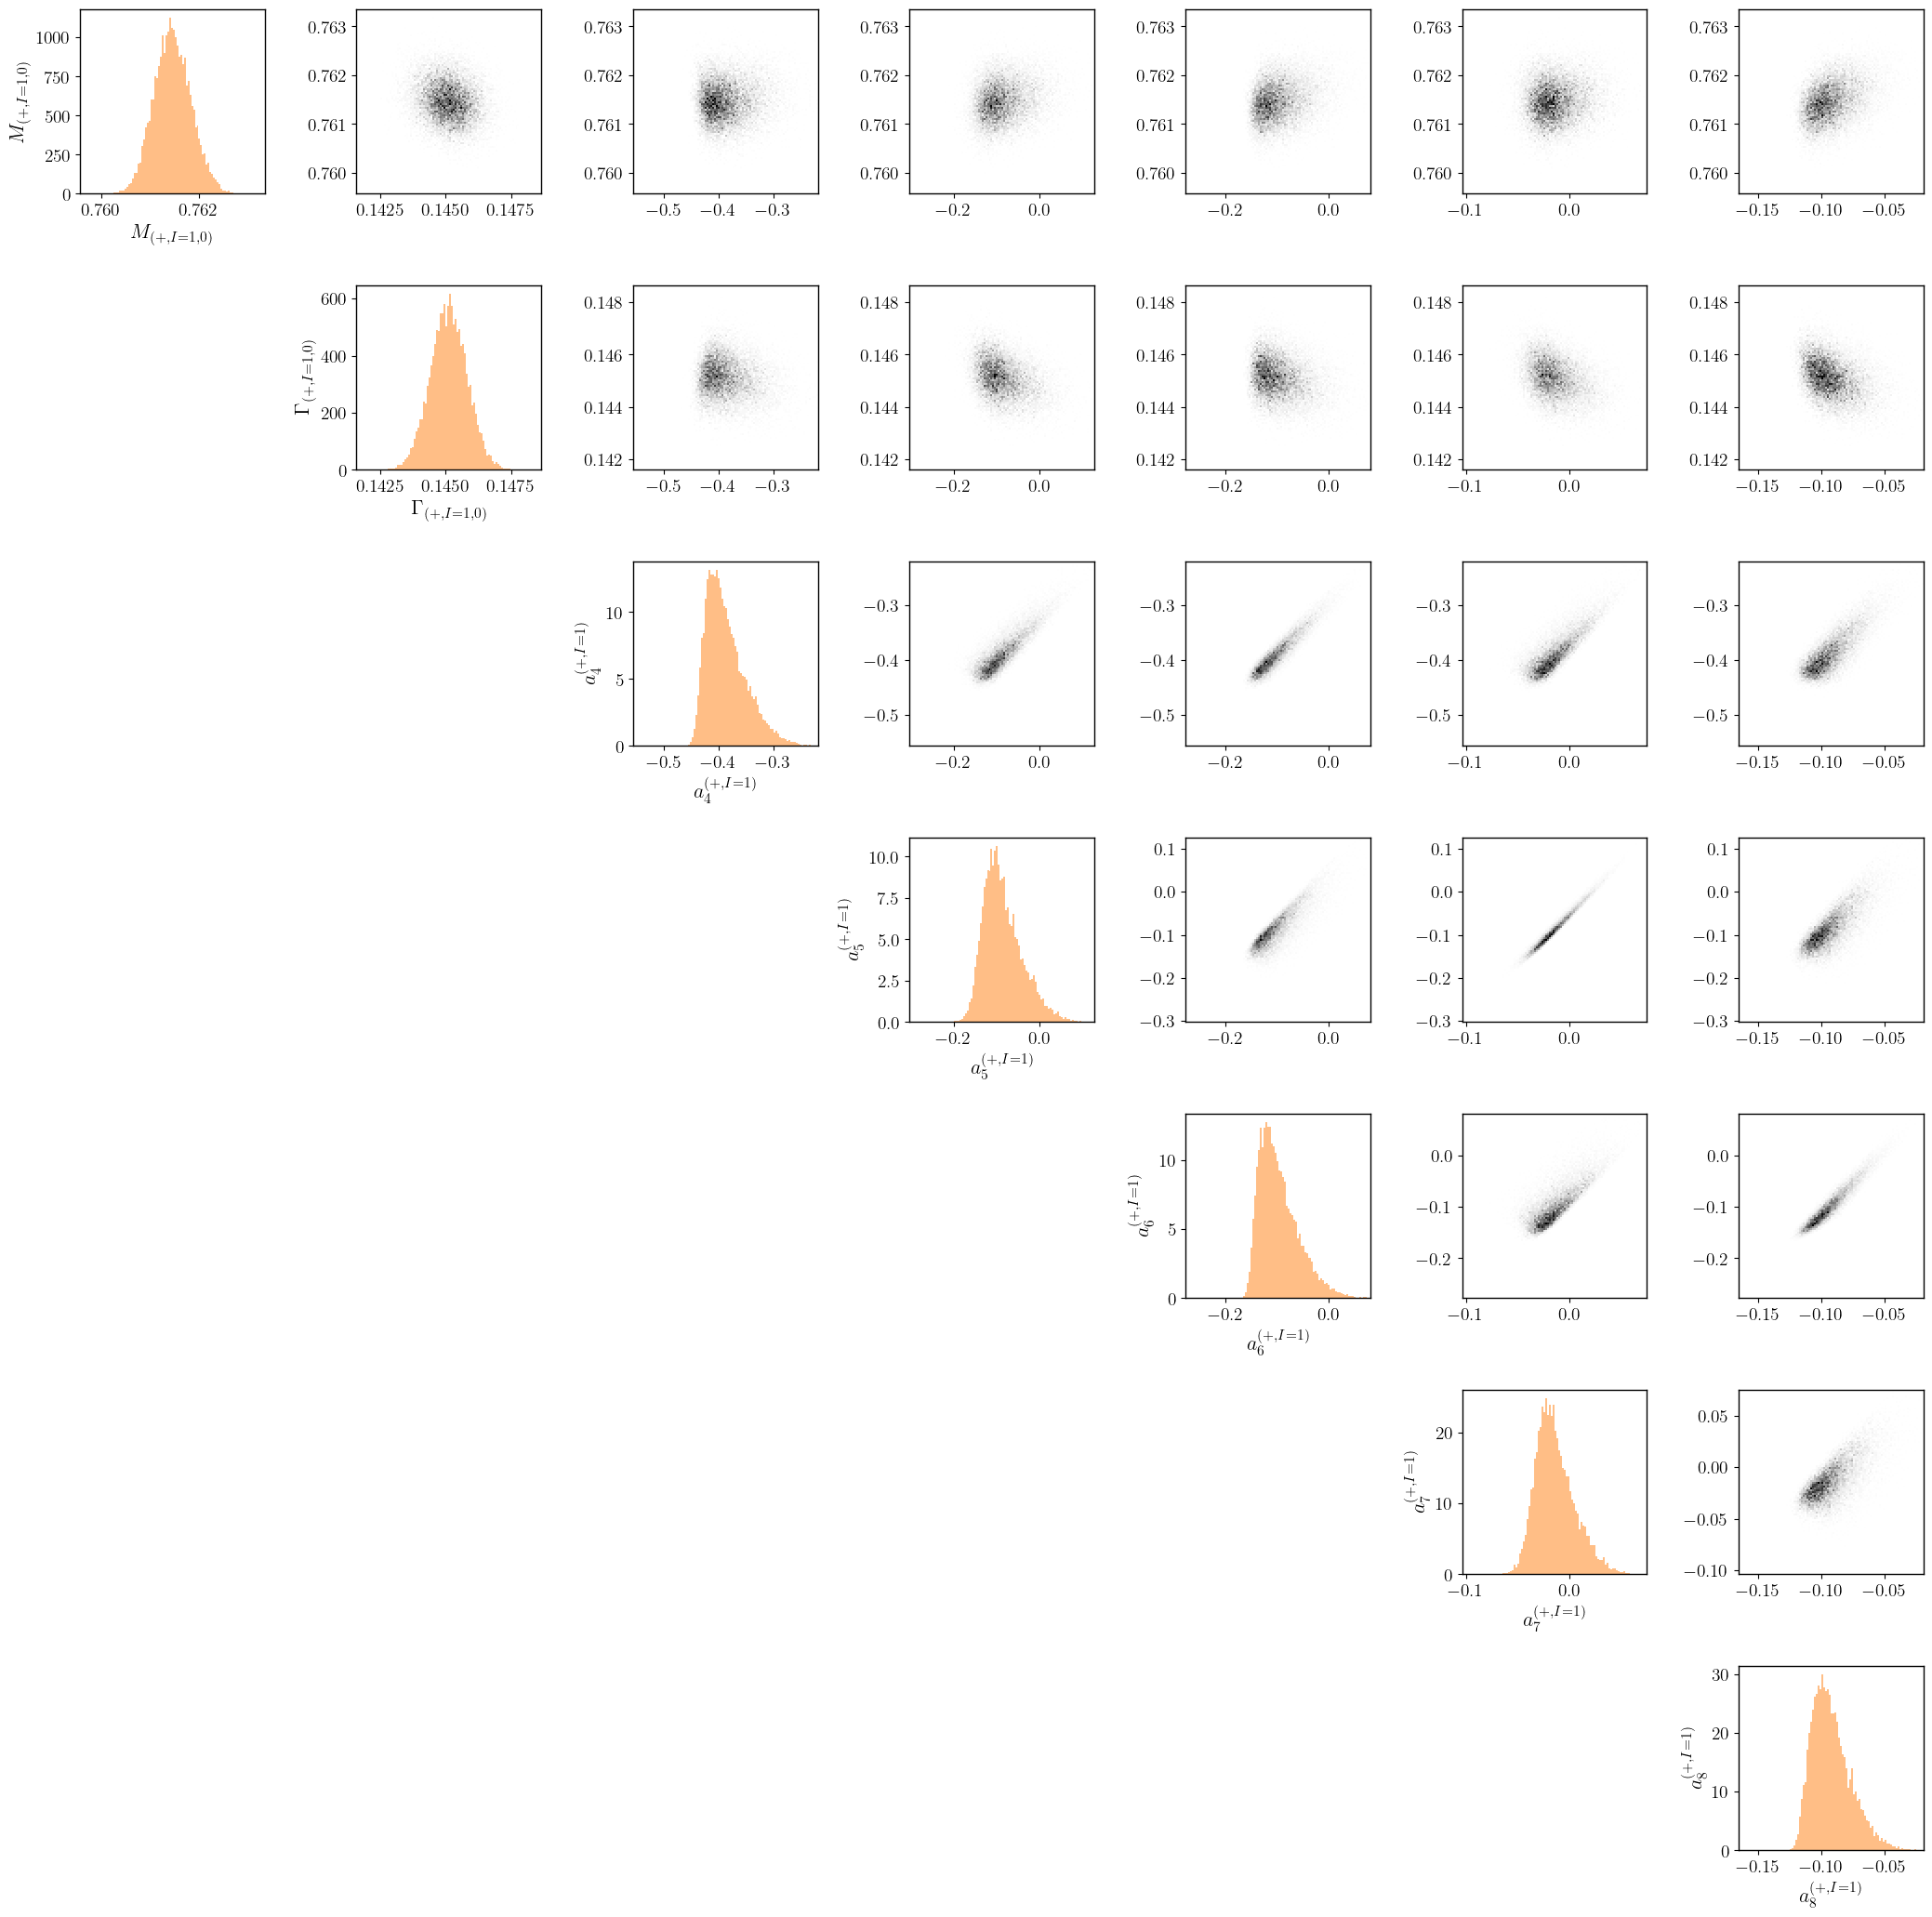

In [39]:
eos.tasks.corner_plot(af, posterior, base_directory=BASE_DIRECTORY)

In [40]:
print(f"rho mass  = {np.average(f.samples[:,0], weights=f.weights):.4f} ± {wstd(f.samples[:,0], weights=f.weights):.4f}")
print(f"rho width = {np.average(f.samples[:,1], weights=f.weights):.4f} ± {wstd(f.samples[:,1], weights=f.weights):.4f}")

rho mass  = 0.7615 ± 0.0004
rho width = 0.1451 ± 0.0007


In [41]:
# Dispersive bound computation
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-dispersive-bound", base_directory=BASE_DIRECTORY)
preds = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-dispersive-bound'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8/pr…

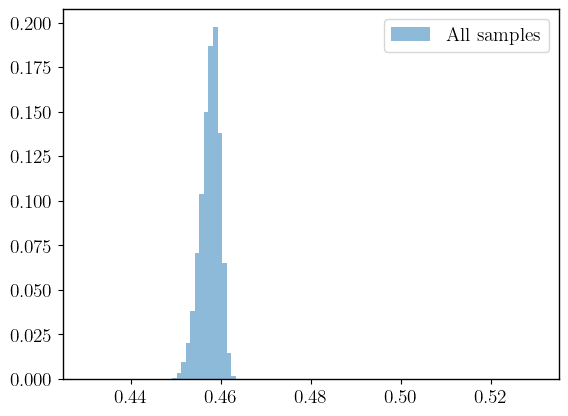

In [42]:
plt.hist(preds.samples, weights=preds.weights, bins=np.linspace(0.43,0.53,100), alpha=0.5, label='All samples')
plt.legend()
plt.show()

In [43]:
disp_values = np.array(preds.samples[:,0])
disp_mean   = np.average(disp_values, weights=preds.weights)
disp_std    = wstd(disp_values, weights=preds.weights)
print(f"Dispersive bound is {disp_mean:.4f} ± {disp_std:.4f}")

Dispersive bound is 0.4576 ± 0.0021


In [44]:
eos.tasks.predict_observables(af, posterior, "FF-fp2-I1-all", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8/pr…

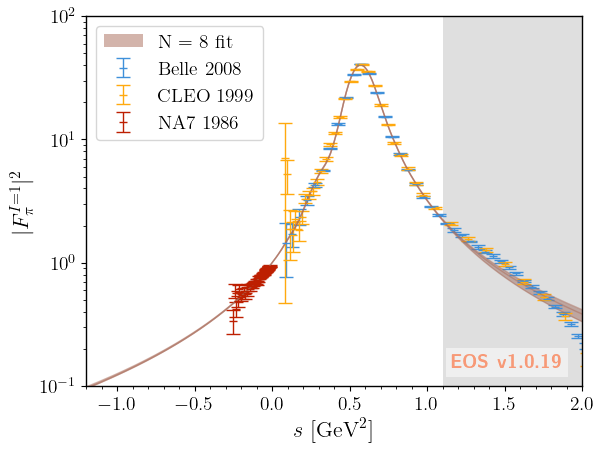

In [45]:
figure_args = {
'watermark': { 'position': 'lower right' },
'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [-1.2, 2.0] },
    'yaxis': { 'label': r'$|F^{I=1}_\pi|^2$', 'range': [ 0.1, 100.0], 'scale': 'log' },
    'legend': { 'position': 'upper left' },
    'items': [
    { 'type': 'constraint', 'label': 'Belle 2008', 'color': colors[0],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2)',
        'constraints': '0->pipi::Abs{f_+}^2@Belle:2008C',
    },
    { 'type': 'constraint', 'label': 'CLEO 1999', 'color': colors[1],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2)',
        'constraints': '0->pipi::Abs{f_+}^2@CLEO:2000B',
    },
    { 'type': 'constraint', 'label': 'NA7 1986', 'color': colors[2],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2)',
        'constraints': '0->pipi::Abs{f_+}^2@NA7:1986A',
    },
    { 'type': 'uncertainty', 'label': 'N = 8 fit', 'color': colors[5],
        'variable': 'q2', 'range': [-1.2, 2.0], 'interpolation': 'cubic',
        'datafile': 'data/'+posterior+'/pred-FF-fp2-I1-all', 'resolution': 300
    },
    { 'type': 'band', 'color': 'gray', 'alpha': 0.25, 'x': [1.1, 2.0], 'y': [0.0, 100]}
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [46]:
eos.tasks.predict_observables(af, posterior, "FF-arg-fp-I1-timelike", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8/pr…

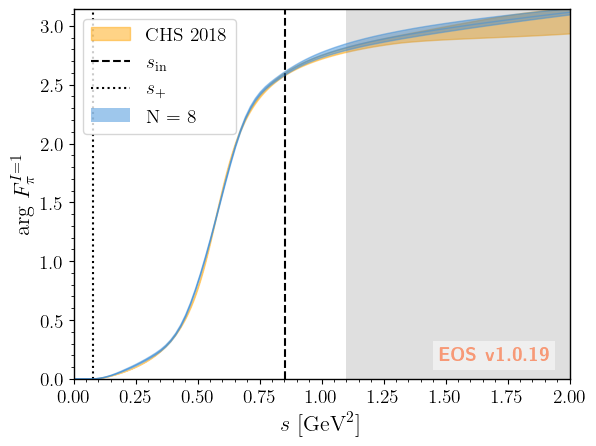

In [47]:
figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [0.0, 2.0] },
    'yaxis': { 'label': r'arg $F^{I=1}_\pi$', 'range': [0.0 , np.pi] },
    'legend': { 'position': 'upper left' },
    'items': [
      { 'type': 'uncertainty', 'label': 'N = 8', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-FF-arg-fp-I1-timelike', 'color': colors[0]
      },
      { 'type': 'band', 'color': 'gray', 'alpha': 0.25, 'x': [1.1, 2.0], 'y': [0.0, np.pi]}
    ]
  }
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)

q2_over_mpisquared, phase, err = np.loadtxt("scripts/d11-central.txt", skiprows=1, unpack=True)
mpi = eos.Parameters()["mass::pi^+"].evaluate()
q2  = q2_over_mpisquared * mpi**2

figure._ax.fill_between(q2, phase-err, phase+err, label="CHS 2018", alpha=0.5, color=colors[1])
figure._ax.plot([sIn, sIn], [0.0, np.pi], color='k', linestyle='--', label= r'$s_\mathrm{in}$')
figure._ax.plot([sPlus, sPlus], [0.0, np.pi], color='k', linestyle=':', label= r'$s_+$')
figure._ax.legend(loc="upper left")

figure.draw()

In [48]:
get_gof(analysis, start_point)
analysis.parameters.dump('data/'+posterior+'/mode-default/parameters.yaml')

Handling item to plot 0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026 in the complex plane
Overriding parameters from file
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,2)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(0,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(0,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,2)@KSvD2025' with central value '0'
[parameters.override] Overriding existing p

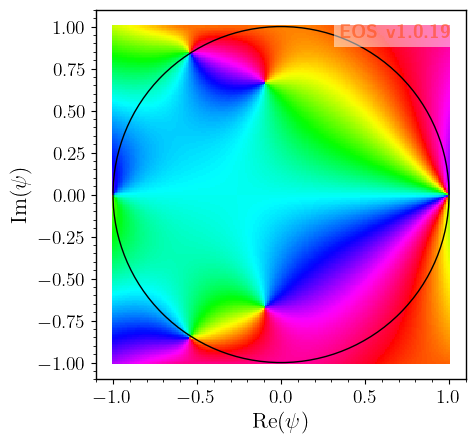

In [51]:
figure_args = {
'plot': {
    'xaxis': { 'label': r'$\mathrm{Re}(\psi)$', 'range': [-1.1, 1.1] },
    'yaxis': { 'label': r'$\mathrm{Im}(\psi)$', 'range': [-1.1, 1.1] },
    # 'legend': { 'position': 'upper left' },
    'items': [
    { 'type': 'complex-plane', 'label': 'N = 8 fit', 'colormap': 'hsv',
        'variables': ["Re{psi}", "Im{psi}"], 'observable': "0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026",
        'fixed_parameters_from_file': 'data/'+posterior+'/mode-default/parameters.yaml', 'resolution': 200
    }
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()
circle = plt.Circle((0, 0), 1.0, color='k', fill=False)
figure._ax.add_patch(circle)
figure._ax.set_aspect("equal", adjustable="box")

In [64]:
eos.tasks.predict_observables(af, posterior, "real-partial-wave-I1", base_directory=BASE_DIRECTORY)
eos.tasks.predict_observables(af, posterior, "imag-partial-wave-I1", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8/pr…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8/pr…

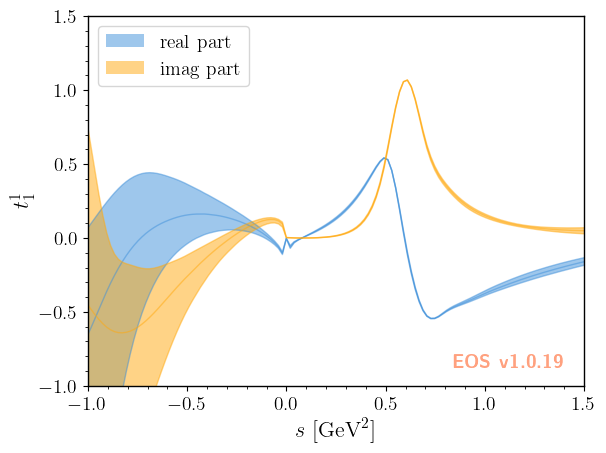

In [65]:
figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [-1.0, 1.5] },
    'yaxis': { 'label': '$t_1^1$', 'range': [-1.0, 1.5]},
    'legend': { 'position': 'upper left' },
    'items': [
      { 'type': 'uncertainty', 'label': 'real part', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-real-partial-wave-I1'
      },
      { 'type': 'uncertainty', 'label': 'imag part', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-imag-partial-wave-I1'
      },
    ]
  }
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [54]:
# Analytic value of a11
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-scattering-length-params", base_directory=BASE_DIRECTORY)
sl_params = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-scattering-length-params'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8/pr…

In [55]:
a11_values = np.array(list(map(a11_calculator, sl_params.samples))) * mpi**2
a11_mean   = np.average(a11_values, weights=sl_params.weights)
a11_std    = wstd(a11_values, weights=sl_params.weights)
print(f"a11 = {a11_mean:.4f} ± {a11_std:.4f}")

a11 = 0.0139 ± 0.0015


In [56]:
# Charge radius
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-pion-charge-radius-param", base_directory=BASE_DIRECTORY)
fprime_values = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-pion-charge-radius-param'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8/pr…

In [57]:
charge_radius_squared_values = np.array(list(map(charge_radius_squared_calculator, fprime_values.samples[:, 0])))
radius_mean = np.average(charge_radius_squared_values, weights=fprime_values.weights)
radius_std  = wstd(charge_radius_squared_values, weights=fprime_values.weights)
print(f"<r^2> = {radius_mean:.4f} ± {radius_std:.4f} fm^2")

<r^2> = 0.4256 ± 0.0037 fm^2


In [58]:
# Residue at the rho pole
eos.tasks.predict_observables(af, posterior, "re-rho-residue-psi", base_directory=BASE_DIRECTORY)
re_res_psi = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-re-rho-residue-psi'))
eos.tasks.predict_observables(af, posterior, "im-rho-residue-psi", base_directory=BASE_DIRECTORY)
im_res_psi = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-im-rho-residue-psi'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8/pr…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8/pr…

In [59]:
re_res = re_res_psi.samples[:,0]
im_res = im_res_psi.samples[:,0]
M      = f.samples[:,0]
Gamma  = f.samples[:,1]

print(len(re_res), len(im_res), len(M), len(Gamma)) # check that they have the same length

14520 14520 14520 14520


In [60]:
data = []

for r, i, m, g in zip(re_res, im_res, M, Gamma):
    data.append([r, i, m, g])
with open("residues_psi_order8.wl", "w") as file:
    lines = [f"{{{r}, {i}, {m}, {g}}}" for r, i, m, g in data]
    file.write("{\n" + ",\n".join(lines) + "\n}")

In [108]:
with open("residues_s_order8.wl") as file:
    text = file.read()

# Replace Mathematica braces with Python brackets
text = text.replace("{", "[").replace("}", "]")

data = ast.literal_eval(text)

In [109]:
res_s       = np.array([re + 1j * im for re, im in data])
res_s_mean  = np.average(res_s, weights=f.weights)
radius_std  = wstd(res_s, weights=f.weights)
print(f"residue at s_rho is ({np.real(res_s_mean):.4f} ± {np.real(radius_std):.4f}) + i * ({np.imag(res_s_mean):.4f} ± {np.imag(radius_std):.4f})")

residue at s_rho is (-0.7516 ± 0.0066) + i * (0.3342 ± 0.0133)


In [110]:
# Computing g_{rho pi pi} and g_{rho gamma}
f_at_s_rho       = np.array([get_f_rho(s, analysis) for s in f.samples])
f_at_s_rho_value = f_at_s_rho[:,0] + 1j * f_at_s_rho[:,1]

In [111]:
s_rho       = (M - 1j * Gamma / 2)**2
g_rho_gamma = np.sqrt(24j * np.pi * s_rho / f_at_s_rho_value / res_s / (np.sqrt(1 - sPlus / s_rho))**3)
g_rho_pi_pi = (- res_s / s_rho) * g_rho_gamma

In [112]:
g_rho_gamma_mean = np.average(g_rho_gamma, weights=f.weights)
g_rho_gamma_std  = wstd(g_rho_gamma, weights=f.weights)
print(f"g_rho_gamma =  ({np.real(g_rho_gamma_mean):.4f} ± {np.real(g_rho_gamma_std):.4f}) + i * ({np.imag(g_rho_gamma_mean):.4f} ± {np.imag(g_rho_gamma_std):.4f})")

g_rho_pi_pi_mean = np.average(g_rho_pi_pi, weights=f.weights)
g_rho_pi_pi_std  = wstd(g_rho_pi_pi, weights=f.weights)
print(f"g_rho_pi_pi =  ({np.real(g_rho_pi_pi_mean):.4f} ± {np.real(g_rho_pi_pi_std):.4f}) + i * ({np.imag(g_rho_pi_pi_mean):.4f} ± {np.imag(g_rho_pi_pi_std):.4f})")

g_rho_gamma =  (4.5310 ± 0.0008) + i * (0.1974 ± -0.0060)
g_rho_pi_pi =  (6.2873 ± 0.0225) + i * (-1.1779 ± 0.0992)


## 0 -> pi pi order 9


In [11]:
posterior = 'FF-fp-I1-order9'
analysis  = af.analysis(posterior)

Creating analysis with 8 priors, 3 EOS-wide constraints, 2 global options, 2 manually-entered constraints and 2 fixed parameters.
likelihood probably depends on 9 parameter(s) that do not appear in the prior; check prior?


In [12]:
start_point = [0.76134058,  0.14494164, -0.42424748, -0.11049332, -0.13978224,
       -0.03200877, -0.10754131, -0.0070655]

In [13]:
get_gof(analysis, start_point)

In [69]:
#bfp, gof = eos.tasks.find_mode(af, posterior, start_point=start_point, base_directory=BASE_DIRECTORY, optimizations=100)
bfp, gof = eos.tasks.find_mode(af, posterior, importance_samples=True, base_directory=BASE_DIRECTORY, optimizations=100)
display(gof)
bfp.point

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9/mo…

array([ 0.76134058,  0.14494164, -0.42424748, -0.11049332, -0.13978224,
       -0.03200877, -0.10754131, -0.0070655 ])

In [14]:
if resample:
    eos.tasks.sample_nested(af, posterior, base_directory=BASE_DIRECTORY, bound='multi', nlive=200)

f = eos.data.ImportanceSamples(os.path.join(BASE_DIRECTORY, 'data', posterior, 'samples'))
print(f"Collected {f.samples.shape[0]} samples")

Collected 14251 samples


In [15]:
for i, p in enumerate(analysis.varied_parameters):
    mean = np.average(f.samples[:,i], weights=f.weights)
    std  = wstd(f.samples[:,i], weights=f.weights)
    print(f"      - {{ 'parameter': '{p.name()}', 'min':  {mean - 5*std:.5f}, 'max':  {mean + 5*std:.5f}, 'type': 'uniform'}}")

      - { 'parameter': '0->pipi::M_(+,1,0)@BHKMNR2026', 'min':  0.75953, 'max':  0.76347, 'type': 'uniform'}
      - { 'parameter': '0->pipi::Gamma_(+,1,0)@BHKMNR2026', 'min':  0.14149, 'max':  0.14870, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^4@BHKMNR2026', 'min':  -0.57378, 'max':  -0.19183, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^5@BHKMNR2026', 'min':  -0.32859, 'max':  0.15047, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^6@BHKMNR2026', 'min':  -0.29056, 'max':  0.11007, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^7@BHKMNR2026', 'min':  -0.19802, 'max':  0.15111, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^8@BHKMNR2026', 'min':  -0.16886, 'max':  -0.00831, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^9@BHKMNR2026', 'min':  -0.07644, 'max':  0.06644, 'type': 'uniform'}


Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9/pl…

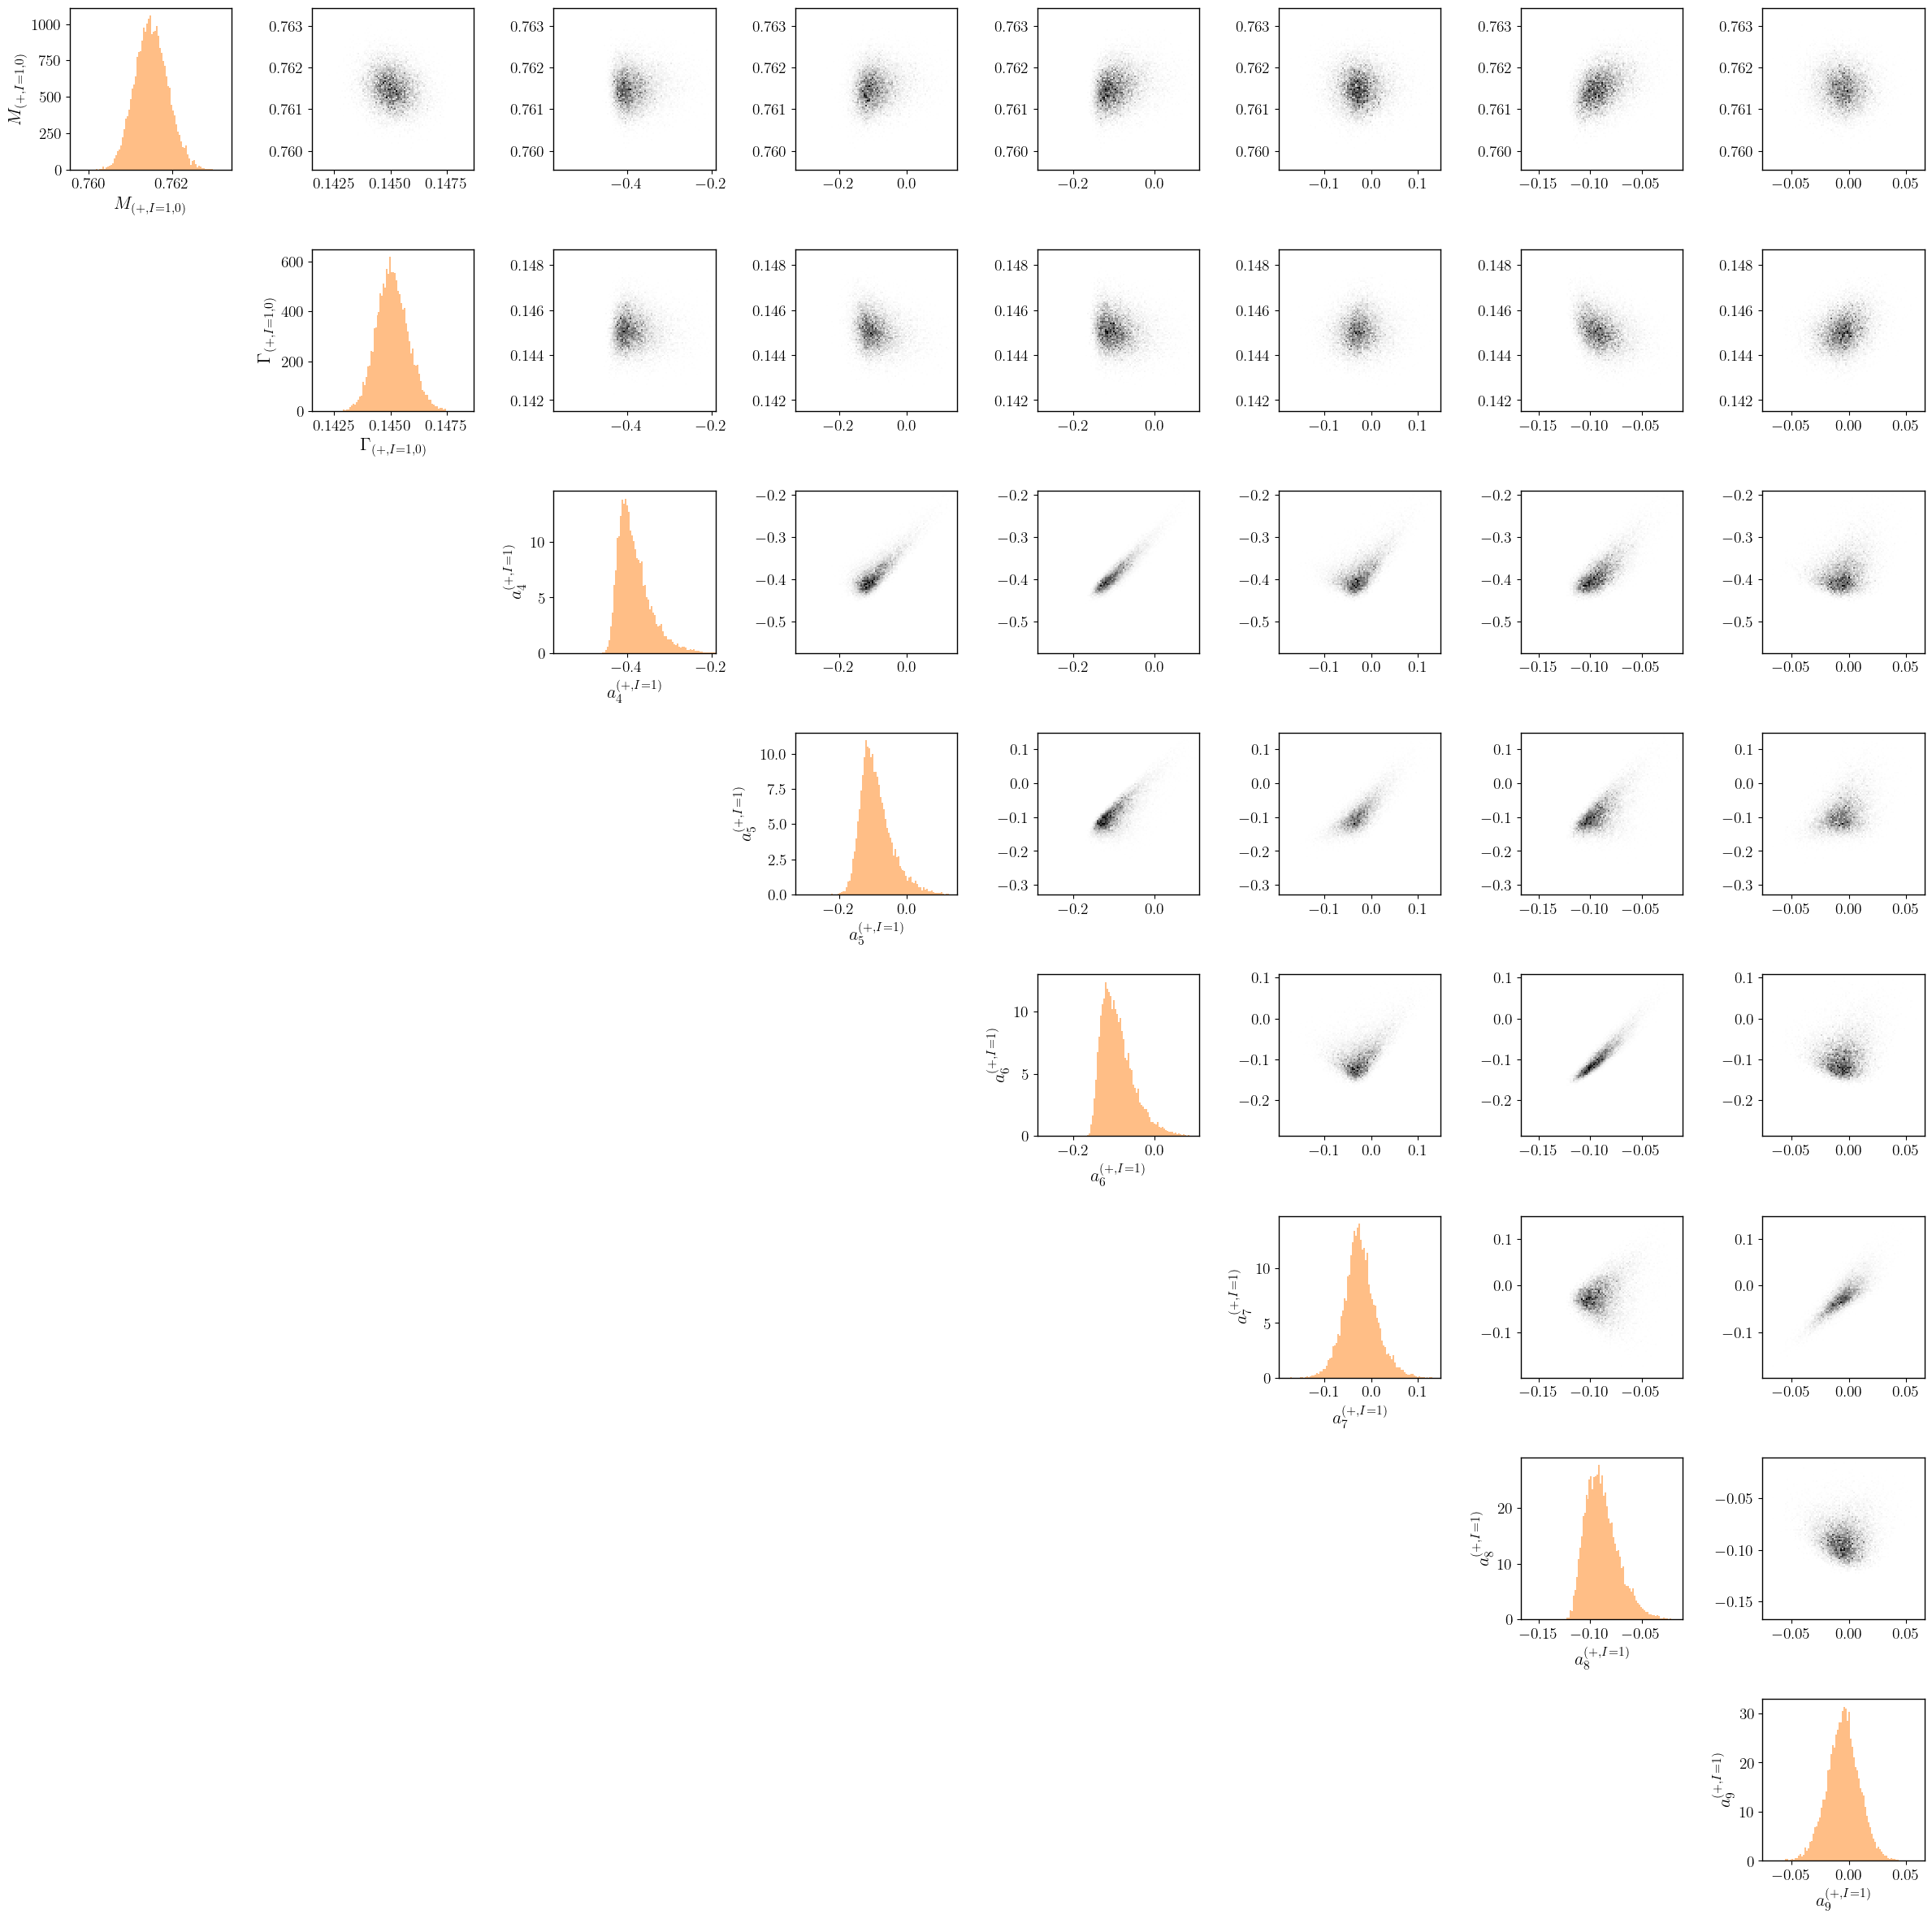

In [72]:
eos.tasks.corner_plot(af, posterior, base_directory=BASE_DIRECTORY)

In [16]:
print(f"rho mass  = {np.average(f.samples[:,0], weights=f.weights):.4f} ± {wstd(f.samples[:,0], weights=f.weights):.4f}")
print(f"rho width = {np.average(f.samples[:,1], weights=f.weights):.4f} ± {wstd(f.samples[:,1], weights=f.weights):.4f}")

rho mass  = 0.7615 ± 0.0004
rho width = 0.1451 ± 0.0007


In [17]:
# Dispersive bound computation
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-dispersive-bound", base_directory=BASE_DIRECTORY)
preds = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-dispersive-bound'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9/pr…

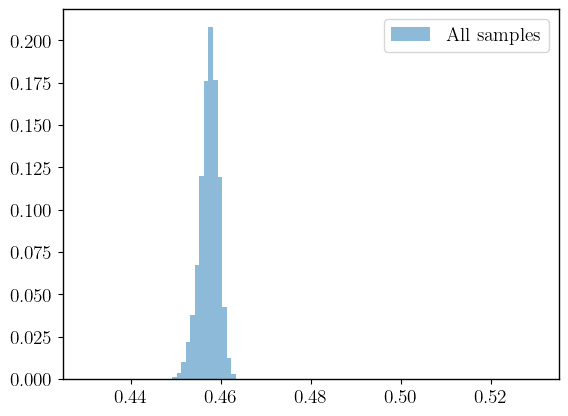

In [18]:
plt.hist(preds.samples, weights=preds.weights, bins=np.linspace(0.43,0.53,100), alpha=0.5, label='All samples')
plt.legend()
plt.show()

In [19]:
disp_values = np.array(preds.samples[:,0])
disp_mean   = np.average(disp_values, weights=preds.weights)
disp_std    = wstd(disp_values, weights=preds.weights)
print(f"Dispersive bound is {disp_mean:.4f} ± {disp_std:.4f}")

Dispersive bound is 0.4574 ± 0.0021


In [20]:
eos.tasks.predict_observables(af, posterior, "FF-fp2-I1-all", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9/pr…

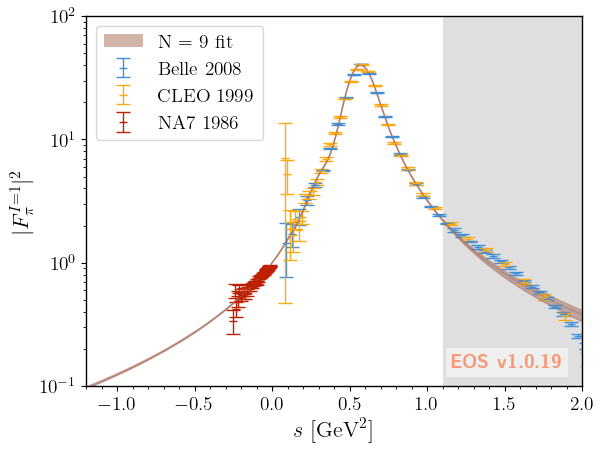

In [21]:
figure_args = {
'watermark': { 'position': 'lower right' },
'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [-1.2, 2.0] },
    'yaxis': { 'label': r'$|F^{I=1}_\pi|^2$', 'range': [ 0.1, 100.0], 'scale': 'log' },
    'legend': { 'position': 'upper left' },
    'items': [
    { 'type': 'constraint', 'label': 'Belle 2008', 'color': colors[0],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2)',
        'constraints': '0->pipi::Abs{f_+}^2@Belle:2008C',
    },
    { 'type': 'constraint', 'label': 'CLEO 1999', 'color': colors[1],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2)',
        'constraints': '0->pipi::Abs{f_+}^2@CLEO:2000B',
    },
    { 'type': 'constraint', 'label': 'NA7 1986', 'color': colors[2],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2)',
        'constraints': '0->pipi::Abs{f_+}^2@NA7:1986A',
    },
    { 'type': 'uncertainty', 'label': 'N = 9 fit', 'color': colors[5],
        'variable': 'q2', 'range': [-1.2, 2.0], 'interpolation': 'cubic',
        'datafile': 'data/'+posterior+'/pred-FF-fp2-I1-all', 'resolution': 300
    },
    { 'type': 'band', 'color': 'gray', 'alpha': 0.25, 'x': [1.1, 2.0], 'y': [0.0, 100]}
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [22]:
eos.tasks.predict_observables(af, posterior, "FF-arg-fp-I1-timelike", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9/pr…

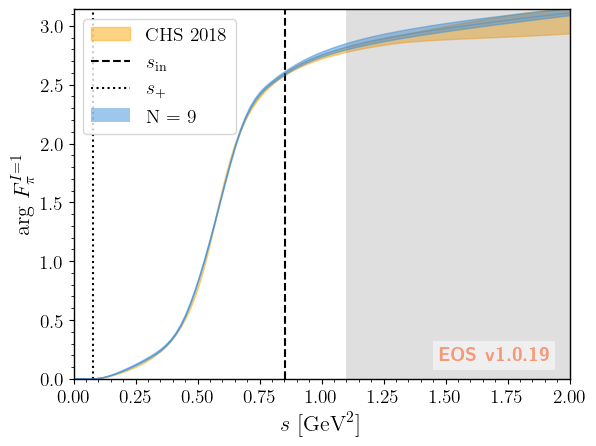

In [23]:
figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [0.0, 2.0] },
    'yaxis': { 'label': r'arg $F^{I=1}_\pi$', 'range': [0.0 , np.pi] },
    'legend': { 'position': 'upper left' },
    'items': [
      { 'type': 'uncertainty', 'label': 'N = 9', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-FF-arg-fp-I1-timelike', 'color': colors[0]
      },
      { 'type': 'band', 'color': 'gray', 'alpha': 0.25, 'x': [1.1, 2.0], 'y': [0.0, np.pi]}
    ]
  }
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)

q2_over_mpisquared, phase, err = np.loadtxt("scripts/d11-central.txt", skiprows=1, unpack=True)
mpi = eos.Parameters()["mass::pi^+"].evaluate()
q2  = q2_over_mpisquared * mpi**2

figure._ax.fill_between(q2, phase-err, phase+err, label="CHS 2018", alpha=0.5, color=colors[1])
figure._ax.plot([sIn, sIn], [0.0, np.pi], color='k', linestyle='--', label= r'$s_\mathrm{in}$')
figure._ax.plot([sPlus, sPlus], [0.0, np.pi], color='k', linestyle=':', label= r'$s_+$')
figure._ax.legend(loc="upper left")

figure.draw()

In [24]:
get_gof(analysis, start_point)
analysis.parameters.dump('data/'+posterior+'/mode-default/parameters.yaml')

Handling item to plot 0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026 in the complex plane
Overriding parameters from file
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,2)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(0,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(0,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,2)@KSvD2025' with central value '0'
[parameters.override] Overriding existing p

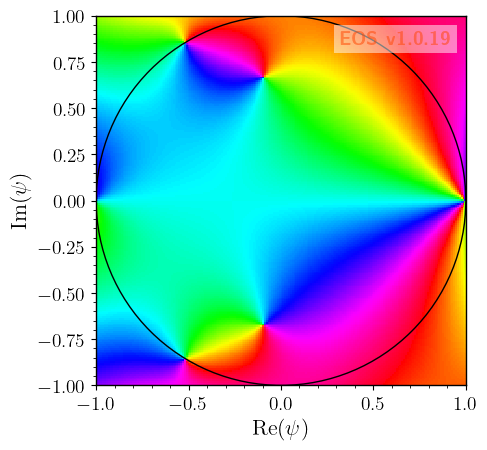

In [27]:
figure_args = {
'plot': {
    'xaxis': { 'label': r'$\mathrm{Re}(\psi)$', 'range': [-1.0, 1.0] },
    'yaxis': { 'label': r'$\mathrm{Im}(\psi)$', 'range': [-1.0, 1.0] },
    # 'legend': { 'position': 'upper left' },
    'items': [
    { 'type': 'complex-plane', 'label': 'N = 9 fit', 'colormap': 'hsv',
        'variables': ["Re{psi}", "Im{psi}"], 'observable': "0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026",
        'fixed_parameters_from_file': 'data/'+posterior+'/mode-default/parameters.yaml', 'resolution': 200
    }
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()
circle = plt.Circle((0, 0), 1.0, color='k', fill=False)
figure._ax.add_patch(circle)
figure._ax.set_aspect("equal", adjustable="box")


In [28]:
eos.tasks.predict_observables(af, posterior, "real-partial-wave-I1", base_directory=BASE_DIRECTORY)
eos.tasks.predict_observables(af, posterior, "imag-partial-wave-I1", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9/pr…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9/pr…

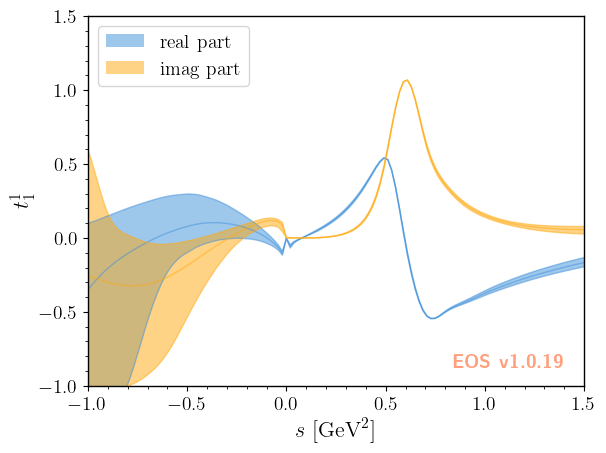

In [31]:
figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [-1.0, 1.5] },
    'yaxis': { 'label': '$t_1^1$', 'range': [-1.0, 1.5]},
    'legend': { 'position': 'upper left' },
    'items': [
      { 'type': 'uncertainty', 'label': 'real part', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-real-partial-wave-I1'
      },
      { 'type': 'uncertainty', 'label': 'imag part', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-imag-partial-wave-I1'
      },
    ]
  }
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [32]:
# Analytic value of a11
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-scattering-length-params", base_directory=BASE_DIRECTORY)
sl_params = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-scattering-length-params'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9/pr…

In [33]:
a11_values = np.array(list(map(a11_calculator, sl_params.samples)))* mpi**2
a11_mean   = np.average(a11_values, weights=sl_params.weights)
a11_std    = wstd(a11_values, weights=sl_params.weights)
print(f"a11 = {a11_mean:.4f} ± {a11_std:.4f}")

a11 = 0.0137 ± 0.0016


In [34]:
# Charge radius
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-pion-charge-radius-param", base_directory=BASE_DIRECTORY)
fprime_values = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-pion-charge-radius-param'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9/pr…

In [35]:
charge_radius_squared_values = np.array(list(map(charge_radius_squared_calculator, fprime_values.samples[:, 0])))
radius_mean  = np.average(charge_radius_squared_values, weights=fprime_values.weights)
radius_std   = wstd(charge_radius_squared_values, weights=fprime_values.weights)

print(f"<r^2> = {radius_mean:.4f} ± {radius_std:.4f} fm^2")

<r^2> = 0.4255 ± 0.0039 fm^2


In [36]:
# Residue at the rho pole
eos.tasks.predict_observables(af, posterior, "re-rho-residue-psi", base_directory=BASE_DIRECTORY)
re_res_psi = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-re-rho-residue-psi'))
eos.tasks.predict_observables(af, posterior, "im-rho-residue-psi", base_directory=BASE_DIRECTORY)
im_res_psi = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-im-rho-residue-psi'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9/pr…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9/pr…

In [37]:
re_res = re_res_psi.samples[:,0]
im_res = im_res_psi.samples[:,0]
M      = f.samples[:,0]
Gamma  = f.samples[:,1]

print(len(re_res), len(im_res), len(M), len(Gamma)) # check that they have the same length

14251 14251 14251 14251


In [38]:
data = []

for r, i, m, g in zip(re_res, im_res, M, Gamma):
    data.append([r, i, m, g])

with open("residues_psi_order9.wl", "w") as file:
    lines = [f"{{{r}, {i}, {m}, {g}}}" for r, i, m, g in data]
    file.write("{\n" + ",\n".join(lines) + "\n}")

In [120]:
with open("residues_s_order9.wl") as file:
    text = file.read()

# Replace Mathematica braces with Python brackets
text = text.replace("{", "[").replace("}", "]")

data = ast.literal_eval(text)

In [121]:
res_s       = np.array([re + 1j * im for re, im in data])
res_s_mean  = np.average(res_s, weights=f.weights)
radius_std  = wstd(res_s, weights=f.weights)
print(f"residue at s_rho is ({np.real(res_s_mean):.4f} ± {np.real(radius_std):.4f}) + i * ({np.imag(res_s_mean):.4f} ± {np.imag(radius_std):.4f})")

residue at s_rho is (-0.7666 ± 0.0135) + i * (0.3188 ± 0.0188)


In [122]:
# Computing g_{rho pi pi} and g_{rho gamma}
f_at_s_rho       = np.array([get_f_rho(s, analysis) for s in f.samples])
f_at_s_rho_value = f_at_s_rho[:,0] + 1j * f_at_s_rho[:,1]

In [123]:
s_rho       = (M - 1j * Gamma / 2)**2
g_rho_gamma = np.sqrt(24j * np.pi * s_rho / f_at_s_rho_value / res_s / (np.sqrt(1 - sPlus / s_rho))**3)
g_rho_pi_pi = - res_s / s_rho * g_rho_gamma

In [124]:
g_rho_gamma_mean = np.average(g_rho_gamma, weights=f.weights)
g_rho_gamma_std  = wstd(g_rho_gamma, weights=f.weights)
print(f"g_rho_gamma =  ({np.real(g_rho_gamma_mean):.4f} ± {np.real(g_rho_gamma_std):.4f}) + i * ({np.imag(g_rho_gamma_mean):.4f} ± {np.imag(g_rho_gamma_std):.4f})")

g_rho_pi_pi_mean = np.average(g_rho_pi_pi, weights=f.weights)
g_rho_pi_pi_std  = wstd(g_rho_pi_pi, weights=f.weights)
print(f"g_rho_pi_pi =  ({np.real(g_rho_pi_pi_mean):.4f} ± {np.real(g_rho_pi_pi_std):.4f}) + i * ({np.imag(g_rho_pi_pi_mean):.4f} ± {np.imag(g_rho_pi_pi_std):.4f})")

g_rho_gamma =  (4.5278 ± 0.0024) + i * (0.2066 ± -0.0096)
g_rho_pi_pi =  (6.3753 ± 0.0710) + i * (-1.0189 ± 0.1670)


## 0 -> pi pi order 10

In [119]:
posterior = 'FF-fp-I1-order10'
analysis  = af.analysis(posterior)

Creating analysis with 9 priors, 3 EOS-wide constraints, 2 global options, 2 manually-entered constraints and 2 fixed parameters.
likelihood probably depends on 8 parameter(s) that do not appear in the prior; check prior?


In [121]:
start_point = [0.76139613,  0.14511096, -0.43060635, -0.11434954, -0.13968883,
       -0.02476555, -0.09977745, -0.00137674,  0.00479275]

In [122]:
get_gof(analysis, start_point)

In [123]:
bfp, gof = eos.tasks.find_mode(af, posterior, start_point=start_point, base_directory=BASE_DIRECTORY, optimizations=100)
# bfp, gof = eos.tasks.find_mode(af, posterior, importance_samples=True, base_directory=BASE_DIRECTORY, optimizations=100)
display(gof)
bfp.point

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order10/m…

array([ 0.76139608,  0.14511105, -0.43060698, -0.1143553 , -0.13968919,
       -0.02476155, -0.09977806, -0.00137266,  0.00479274])

In [93]:
if resample:
    eos.tasks.sample_nested(af, posterior, base_directory=BASE_DIRECTORY, bound='multi', nlive=250)

f = eos.data.ImportanceSamples(os.path.join(BASE_DIRECTORY, 'data', posterior, 'samples'))
print(f"Collected {f.samples.shape[0]} samples")

Collected 17388 samples


In [94]:
for i, p in enumerate(analysis.varied_parameters):
    mean = np.average(f.samples[:,i], weights=f.weights)
    std  = wstd(f.samples[:,i], weights=f.weights)
    print(f"      - {{ 'parameter': '{p.name()}', 'min':  {mean - 5*std:.5f}, 'max':  {mean + 5*std:.5f}, 'type': 'uniform'}}")

      - { 'parameter': '0->pipi::M_(+,1,0)@BHKMNR2026', 'min':  0.75960, 'max':  0.76346, 'type': 'uniform'}
      - { 'parameter': '0->pipi::Gamma_(+,1,0)@BHKMNR2026', 'min':  0.14160, 'max':  0.14899, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^4@BHKMNR2026', 'min':  -0.61372, 'max':  -0.13969, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^5@BHKMNR2026', 'min':  -0.39962, 'max':  0.22609, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^6@BHKMNR2026', 'min':  -0.33763, 'max':  0.20819, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^7@BHKMNR2026', 'min':  -0.25262, 'max':  0.22252, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^8@BHKMNR2026', 'min':  -0.25736, 'max':  0.14656, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^9@BHKMNR2026', 'min':  -0.08810, 'max':  0.08656, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^10@BHKMNR2026', 'min':  -0.06630, 'max':  0.09467, 'type': 'uniform'}


Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order10/p…

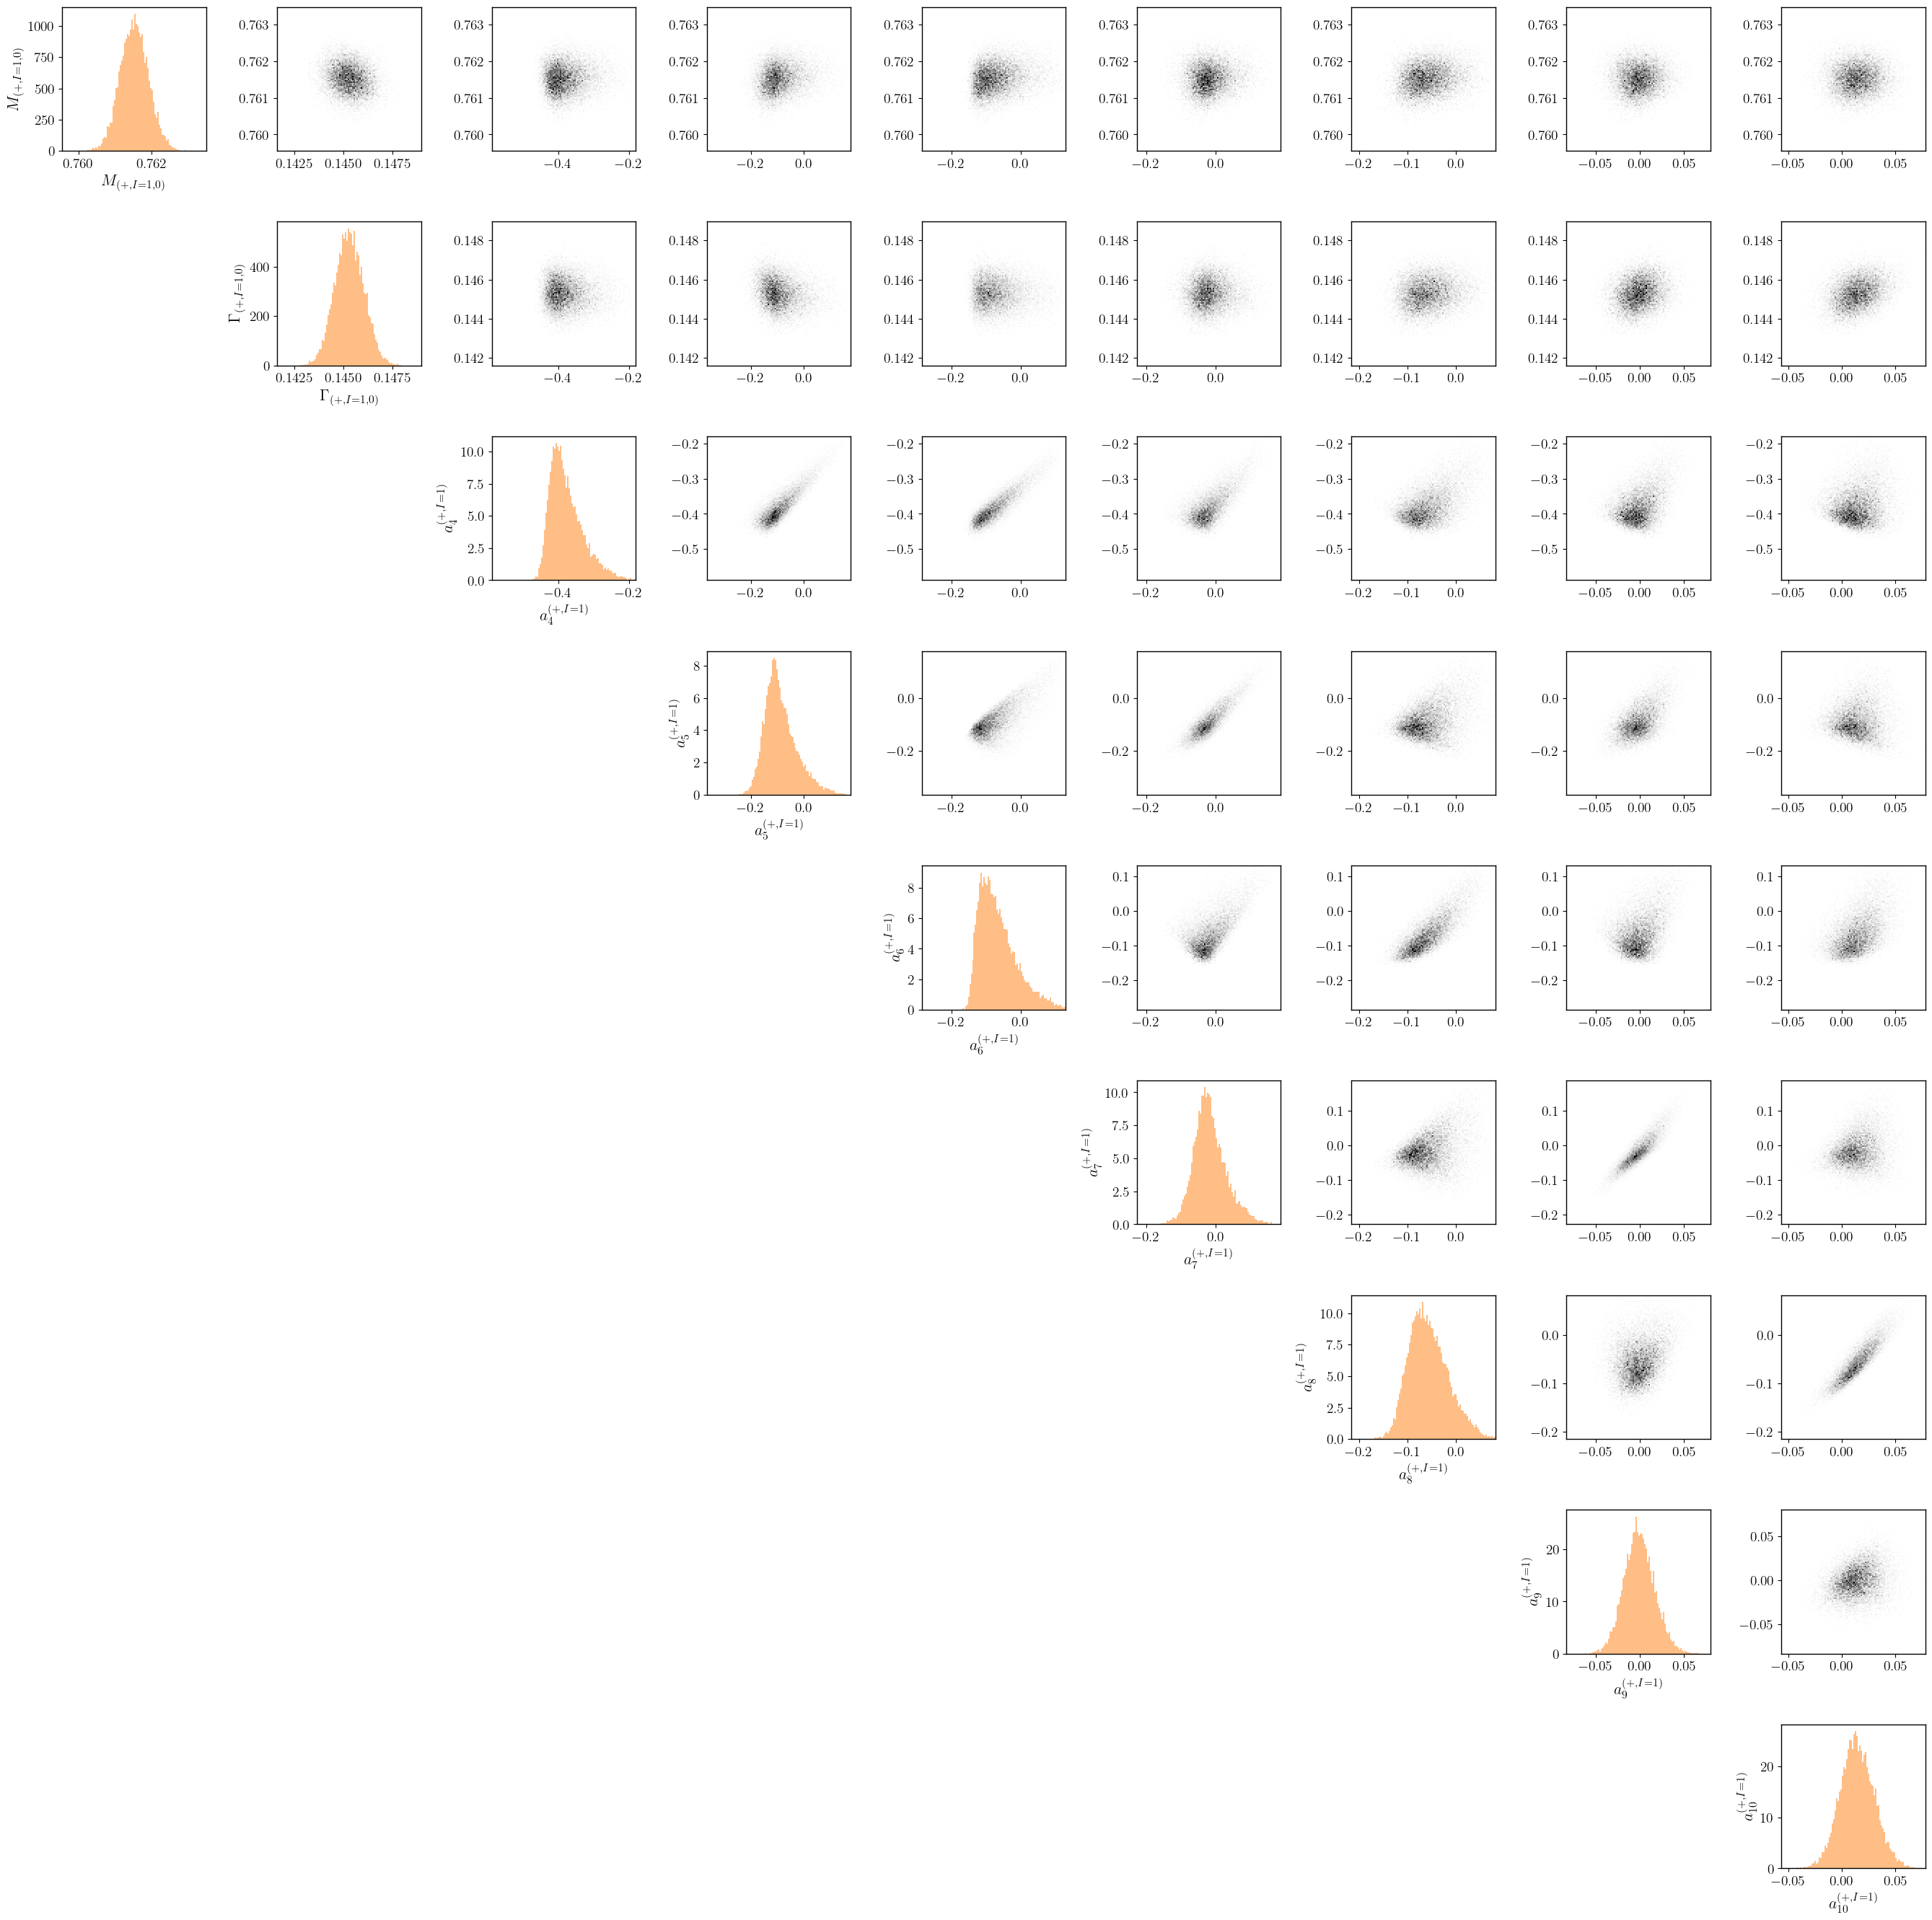

In [95]:
eos.tasks.corner_plot(af, posterior, base_directory=BASE_DIRECTORY)

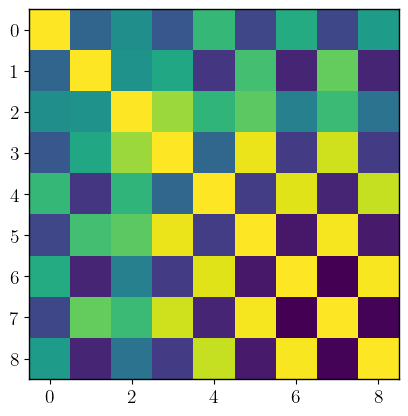

In [17]:
means = np.average(f.samples, weights=f.weights, axis=0)
cov = np.cov(f.samples, rowvar=False, aweights=f.weights)
corr = np.array([[cov[i,j] / np.sqrt(cov[i,i] * cov[j,j]) for j in range(len(cov))] for i in range(len(cov))])
plt.imshow(corr)
plt.show()

In [18]:
chol = np.linalg.cholesky(np.linalg.inv(cov))
display(np.linalg.inv(chol.transpose()))
decorrelated_samples = np.dot(f.samples, chol)
decorrelated_min = np.average(decorrelated_samples, weights=f.weights, axis=0) - 5 * wstd(decorrelated_samples, weights=f.weights, axis=0)
decorrelated_max = np.average(decorrelated_samples, weights=f.weights, axis=0) + 5 * wstd(decorrelated_samples, weights=f.weights, axis=0)
display(decorrelated_min, decorrelated_max)

array([[ 2.40250561e-04, -4.74254789e-05, -3.17239107e-05,
         2.48841019e-04, -1.50960018e-04, -7.60658608e-05,
         3.13261685e-04, -2.50078802e-04,  1.09270425e-04],
       [ 0.00000000e+00,  2.99764485e-04, -4.38775795e-04,
         7.85940604e-05,  4.46101049e-04, -4.92986376e-04,
        -5.37055258e-05,  1.44026429e-04, -6.90754248e-04],
       [ 0.00000000e+00,  0.00000000e+00,  2.60424001e-03,
        -9.02997763e-04,  2.20520709e-02,  1.69938723e-02,
         7.64220117e-02,  5.13155847e-02, -1.21630957e-02],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         5.25825554e-03,  6.70285966e-05,  5.72744794e-02,
         4.91955173e-02,  1.47909347e-01, -9.57052120e-02],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  1.22027158e-02,  6.62575784e-03,
         9.32564580e-02,  1.26881821e-02,  1.48529372e-01],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  2.706125

array([ 3.19726935e+03,  2.14455635e+02, -1.76182859e+02, -6.89572119e+00,
        5.10643988e+00, -2.80101712e+00, -9.98357688e+00, -2.16546384e+00,
       -4.84485112e+00])

array([ 3.20726897e+03,  2.24455256e+02, -1.66183239e+02,  3.10389920e+00,
        1.51060603e+01,  7.19860327e+00,  1.60435070e-02,  7.83415655e+00,
        5.15476928e+00])

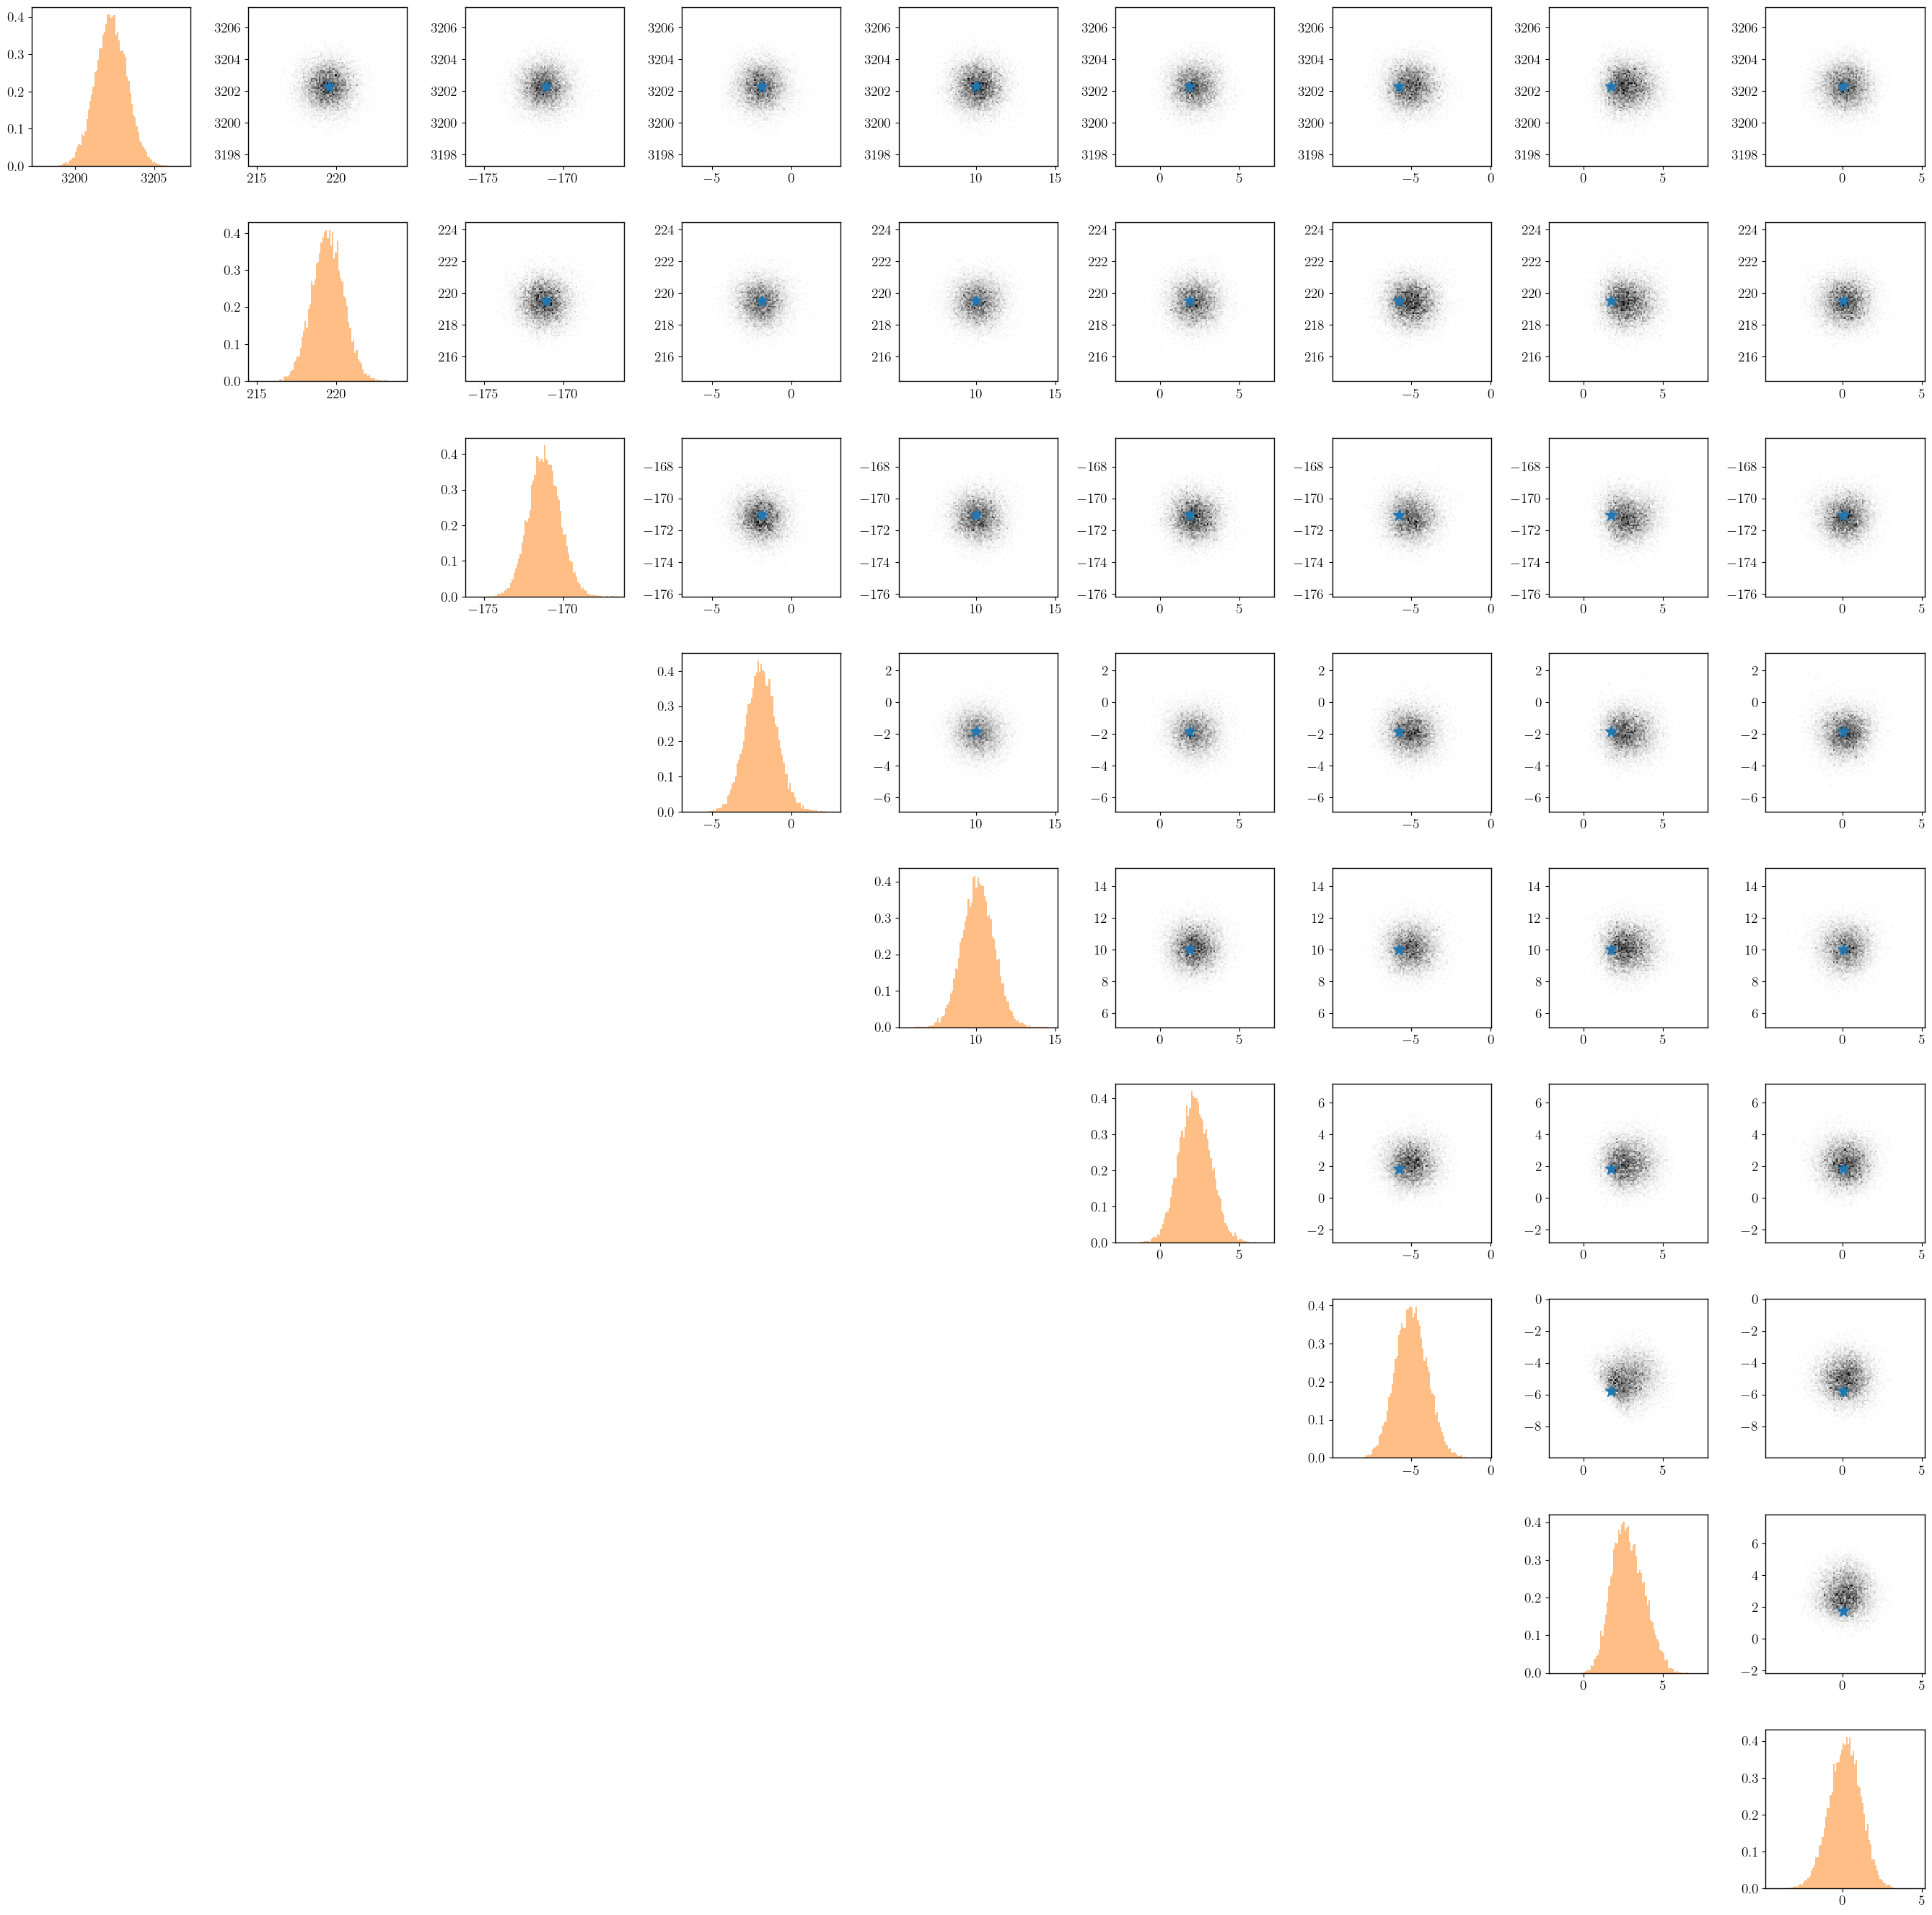

In [19]:
size = decorrelated_samples.shape[-1]
decorrelated_start_point = np.dot(start_point, chol)

fig, axes = plt.subplots(size, size, figsize=(3.0 * size, 3.0 * size), dpi=100)

for i in range(size):
    # diagonal
    ax = axes[i, i]
    variable_samples = decorrelated_samples[:, i] # For a single variable

    xmin = decorrelated_min[i]
    xmax = decorrelated_max[i]
    ax.hist(variable_samples, weights=f.weights, alpha=0.5, bins=np.linspace(xmin, xmax, 100), density=True, stacked=True, color='C1')
    ax.set_xlim((xmin, xmax))
    ax.set_aspect(np.diff((xmin, xmax))[0] / np.diff(ax.get_ylim())[0])

    for j in range(0, size):
        # off-diagonal
        if j < i:
            axes[i, j].set_axis_off()

        if j <= i:
            continue

        ax = axes[i, j]

        ax.plot(decorrelated_start_point[j], decorrelated_start_point[i], marker = "*", markersize=12)

        # Samples for two single variables as x and y data
        xsamples = decorrelated_samples[:, j]
        ysamples = decorrelated_samples[:, i]

        xmin = decorrelated_min[j]
        xmax = decorrelated_max[j]
        ymin = decorrelated_min[i]
        ymax = decorrelated_max[i]
        ax.hist2d(xsamples, ysamples, weights=f.weights, alpha=1.0, bins=[np.linspace(xmin, xmax, 100), np.linspace(ymin, ymax, 100)], cmap='Greys', rasterized=True)
        ax.set_xlim((xmin, xmax))
        ax.set_ylim((ymin, ymax))
        ax.set_aspect(np.diff((xmin, xmax))[0] / np.diff((ymin, ymax))[0])

fig.tight_layout()
fig.show()

In [98]:
print(f"rho mass  = {np.average(f.samples[:,0], weights=f.weights):.4f} ± {wstd(f.samples[:,0], weights=f.weights):.4f}")
print(f"rho width = {np.average(f.samples[:,1], weights=f.weights):.4f} ± {wstd(f.samples[:,1], weights=f.weights):.4f}")

rho mass  = 0.7615 ± 0.0004
rho width = 0.1453 ± 0.0007


In [99]:
# Dispersive bound computation
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-dispersive-bound", base_directory=BASE_DIRECTORY)
preds = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-dispersive-bound'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order10/p…

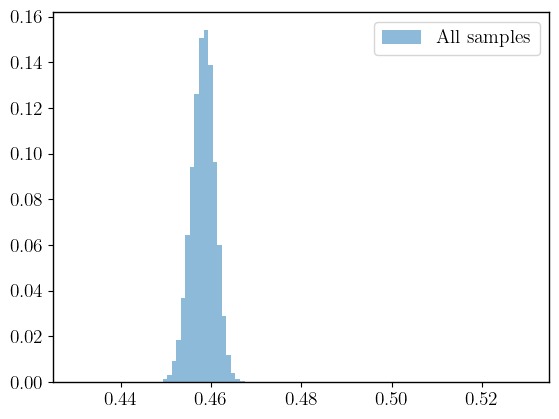

In [100]:
plt.hist(preds.samples, weights=preds.weights, bins=np.linspace(0.43,0.53,100), alpha=0.5, label='All samples')
plt.legend()
plt.show()

In [101]:
disp_values = np.array(preds.samples[:,0])
disp_mean   = np.average(disp_values, weights=preds.weights)
disp_std    = wstd(disp_values, weights=preds.weights)
print(f"Dispersive bound is {disp_mean:.4f} ± {disp_std:.4f}")

Dispersive bound is 0.4582 ± 0.0026


In [102]:
eos.tasks.predict_observables(af, posterior, "FF-fp2-I1-all", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order10/p…

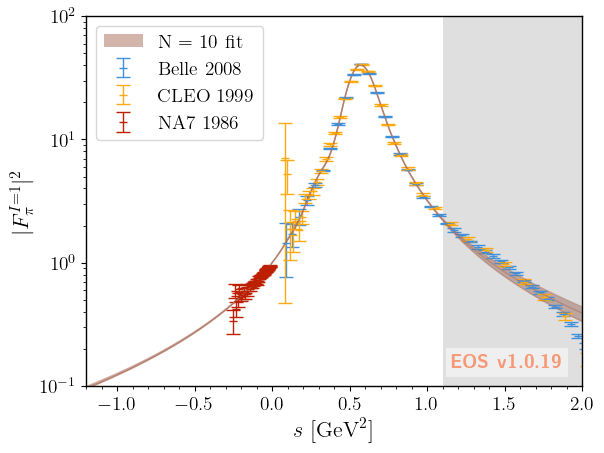

In [103]:
figure_args = {
'watermark': { 'position': 'lower right' },
'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [-1.2, 2.0] },
    'yaxis': { 'label': r'$|F^{I=1}_\pi|^2$', 'range': [ 0.1, 100.0], 'scale': 'log' },
    'legend': { 'position': 'upper left' },
    'items': [
    { 'type': 'constraint', 'label': 'Belle 2008', 'color': colors[0],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2)',
        'constraints': '0->pipi::Abs{f_+}^2@Belle:2008C',
    },
    { 'type': 'constraint', 'label': 'CLEO 1999', 'color': colors[1],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2)',
        'constraints': '0->pipi::Abs{f_+}^2@CLEO:2000B',
    },
    { 'type': 'constraint', 'label': 'NA7 1986', 'color': colors[2],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2)',
        'constraints': '0->pipi::Abs{f_+}^2@NA7:1986A',
    },
    { 'type': 'uncertainty', 'label': 'N = 10 fit', 'color': colors[5],
        'variable': 'q2', 'range': [-1.2, 2.0], 'interpolation': 'cubic',
        'datafile': 'data/'+posterior+'/pred-FF-fp2-I1-all', 'resolution': 300
    },
    { 'type': 'band', 'color': 'gray', 'alpha': 0.25, 'x': [1.1, 2.0], 'y': [0.0, 100]}
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [104]:
eos.tasks.predict_observables(af, posterior, "FF-arg-fp-I1-timelike", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order10/p…

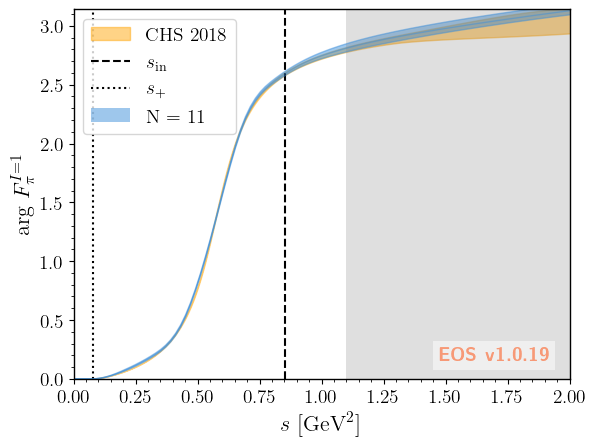

In [105]:
figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [0.0, 2.0] },
    'yaxis': { 'label': r'arg $F^{I=1}_\pi$', 'range': [0.0 , np.pi] },
    'legend': { 'position': 'upper left' },
    'items': [
      { 'type': 'uncertainty', 'label': 'N = 11', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-FF-arg-fp-I1-timelike', 'color': colors[0]
      },
      { 'type': 'band', 'color': 'gray', 'alpha': 0.25, 'x': [1.1, 2.0], 'y': [0.0, np.pi]}
    ]
  }
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)

q2_over_mpisquared, phase, err = np.loadtxt("scripts/d11-central.txt", skiprows=1, unpack=True)
mpi = eos.Parameters()["mass::pi^+"].evaluate()
q2  = q2_over_mpisquared * mpi**2

figure._ax.fill_between(q2, phase-err, phase+err, label="CHS 2018", alpha=0.5, color=colors[1])
figure._ax.plot([sIn, sIn], [0.0, np.pi], color='k', linestyle='--', label= r'$s_\mathrm{in}$')
figure._ax.plot([sPlus, sPlus], [0.0, np.pi], color='k', linestyle=':', label= r'$s_+$')
figure._ax.legend(loc="upper left")

figure.draw()

In [106]:
get_gof(analysis, start_point)
analysis.parameters.dump('data/'+posterior+'/mode-default/parameters.yaml')

Handling item to plot 0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026 in the complex plane
Overriding parameters from file
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,2)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(0,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(0,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,2)@KSvD2025' with central value '0'
[parameters.override] Overriding existing p

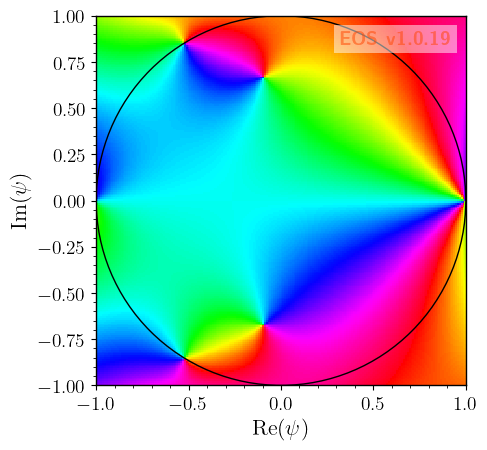

In [108]:
figure_args = {
'plot': {
    'xaxis': { 'label': r'$\mathrm{Re}(\psi)$', 'range': [-1.0, 1.0] },
    'yaxis': { 'label': r'$\mathrm{Im}(\psi)$', 'range': [-1.0, 1.0] },
    # 'legend': { 'position': 'upper left' },
    'items': [
    { 'type': 'complex-plane', 'label': 'N = 10 fit', 'colormap': 'hsv',
        'variables': ["Re{psi}", "Im{psi}"], 'observable': "0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026",
        'fixed_parameters_from_file': 'data/'+posterior+'/mode-default/parameters.yaml', 'resolution': 200
    }
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()
circle = plt.Circle((0, 0), 1.0, color='k', fill=False)
figure._ax.add_patch(circle)
figure._ax.set_aspect("equal", adjustable="box")

In [109]:
eos.tasks.predict_observables(af, posterior, "real-partial-wave-I1", base_directory=BASE_DIRECTORY)
eos.tasks.predict_observables(af, posterior, "imag-partial-wave-I1", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order10/p…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order10/p…

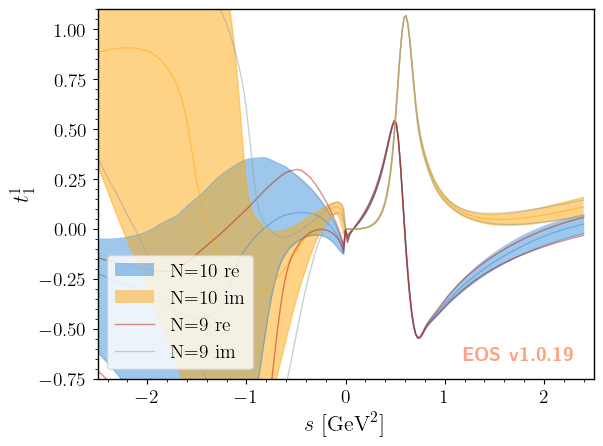

In [110]:
figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [-2.5, 2.5] },
    'yaxis': { 'label': '$t_1^1$',  'range': [-0.75, 1.1]},
    'legend': { 'position': 'lower left' },
    'items': [
      { 'type': 'uncertainty', 'label': 'N=10 re', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-real-partial-wave-I1'
      },
      { 'type': 'uncertainty', 'label': 'N=10 im', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-imag-partial-wave-I1'
      },
      { 'type': 'uncertainty', 'label': 'N=9 re', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/FF-fp-I1-order9/pred-real-partial-wave-I1', 'band': 'outer'
      },
      { 'type': 'uncertainty', 'label': 'N=9 im', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/FF-fp-I1-order9/pred-imag-partial-wave-I1', 'band': 'outer'
      },
    ]
  }
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [111]:
# Analytic value of a11
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-scattering-length-params", base_directory=BASE_DIRECTORY)
sl_params = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-scattering-length-params'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order10/p…

In [112]:
a11_values = np.array(list(map(a11_calculator, sl_params.samples)))* mpi**2
a11_mean   = np.average(a11_values, weights=sl_params.weights)
a11_std    = wstd(a11_values, weights=sl_params.weights)
print(f"a11 = {a11_mean:.4f} ± {a11_std:.4f}")

a11 = 0.0131 ± 0.0020


In [113]:
# Charge radius
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-pion-charge-radius-param", base_directory=BASE_DIRECTORY)
fprime_values = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-pion-charge-radius-param'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order10/p…

In [114]:
charge_radius_squared_values = np.array(list(map(charge_radius_squared_calculator, fprime_values.samples[:, 0])))
radius_mean = np.average(charge_radius_squared_values, weights=fprime_values.weights)
radius_std  = wstd(charge_radius_squared_values, weights=fprime_values.weights)
print(f"<r^2> = {radius_mean:.4f} ± {radius_std:.4f} fm^2")

<r^2> = 0.4252 ± 0.0041 fm^2


In [115]:
# Residue at the rho pole
eos.tasks.predict_observables(af, posterior, "re-rho-residue-psi", base_directory=BASE_DIRECTORY)
re_res_psi = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-re-rho-residue-psi'))
eos.tasks.predict_observables(af, posterior, "im-rho-residue-psi", base_directory=BASE_DIRECTORY)
im_res_psi = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-im-rho-residue-psi'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order10/p…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order10/p…

In [116]:
re_res = re_res_psi.samples[:,0]
im_res = im_res_psi.samples[:,0]
M      = f.samples[:,0]
Gamma  = f.samples[:,1]

print(len(re_res), len(im_res), len(M), len(Gamma)) # check that they have the same length

17388 17388 17388 17388


In [117]:
data = []

for r, i, m, g in zip(re_res, im_res, M, Gamma):
    data.append([r, i, m, g])

with open("residues_psi_order10.wl", "w") as file:
    lines = [f"{{{r}, {i}, {m}, {g}}}" for r, i, m, g in data]
    file.write("{\n" + ",\n".join(lines) + "\n}")

In [40]:
with open("residues_s_order10.wl") as file:
    text = file.read()

# Replace Mathematica braces with Python brackets
text = text.replace("{", "[").replace("}", "]")

data = ast.literal_eval(text)

FileNotFoundError: [Errno 2] No such file or directory: 'residues_s_order10.wl'

In [43]:
res_s       = np.array([re + 1j * im for re, im in data])
res_s_mean  = np.average(res_s, weights=f.weights)
radius_std  = wstd(res_s, weights=f.weights)
print(f"residue at s_rho is ({np.real(res_s_mean):.4f} ± {np.real(radius_std):.4f}) + i * ({np.imag(res_s_mean):.4f} ± {np.imag(radius_std):.4f})")

residue at s_rho is (-0.7360 ± 0.0217) + i * (0.1290 ± 0.0311)


In [46]:
# Computing g_{rho pi pi} and g_{rho gamma}
f_at_s_rho       = np.array([get_f_rho(s, analysis) for s in f.samples])
f_at_s_rho_value = f_at_s_rho[:,0] + 1j * f_at_s_rho[:,1]

In [47]:
s_rho       = (M - 1j * Gamma / 2)**2
g_rho_gamma = np.sqrt(24j * np.pi * s_rho / f_at_s_rho_value / res_s / (np.sqrt(1 - sPlus / s_rho))**3)
g_rho_pi_pi = - res_s / s_rho * g_rho_gamma

In [ ]:
g_rho_gamma_mean = np.average(g_rho_gamma, weights=f.weights)
g_rho_gamma_std  = wstd(g_rho_gamma, weights=f.weights)
print(f"g_rho_gamma = ({np.real(g_rho_gamma_mean):.4f} ± {np.real(g_rho_gamma_std):.4f}) + i * ({np.imag(g_rho_gamma_mean):.4f} ± {np.imag(g_rho_gamma_std):.4f})")

g_rho_pi_pi_mean = np.average(g_rho_pi_pi, weights=f.weights)
g_rho_pi_pi_std  = wstd(g_rho_pi_pi, weights=f.weights)
print(f"g_rho_pi_pi = ({np.real(g_rho_pi_pi_mean):.4f} ± {np.real(g_rho_pi_pi_std):.4f}) + i * ({np.imag(g_rho_pi_pi_mean):.4f} ± {np.imag(g_rho_pi_pi_std):.4f})")


g_rho_gamma = (4.8528 ± 0.0150) + i * (-0.1743 ± -0.0045)
g_rho_pi_pi = (6.2224 ± 0.1286) + i * (-0.1042 ± 0.2898)


## 0 -> pi pi order 11

In [22]:
posterior = 'FF-fp-I1-order11'
analysis  = af.analysis(posterior)

Creating analysis with 10 priors, 3 EOS-wide constraints, 2 global options, 2 manually-entered constraints and 2 fixed parameters.
likelihood probably depends on 7 parameter(s) that do not appear in the prior; check prior?


In [66]:
start_point = [0.76111053,  0.14523742, -0.49938465, -0.20185487, -0.15104768,
       -0.01585493, -0.0424324 ,  0.08152986,  0.03381542,  0.04296708]

In [67]:
get_gof(analysis, start_point)

In [62]:
#bfp, gof = eos.tasks.find_mode(af, posterior, start_point=start_point, base_directory=BASE_DIRECTORY, optimizations=100)
bfp, gof = eos.tasks.find_mode(af, posterior, importance_samples=True, base_directory=BASE_DIRECTORY, optimizations=100)
display(gof)
bfp.point

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order11/m…

array([ 0.76111053,  0.14523742, -0.49938465, -0.20185487, -0.15104768,
       -0.01585493, -0.0424324 ,  0.08152986,  0.03381542,  0.04296708])

In [23]:
if resample:
    eos.tasks.sample_nested(af, posterior, base_directory=BASE_DIRECTORY, bound='multi', nlive=200)

f = eos.data.ImportanceSamples(os.path.join(BASE_DIRECTORY, 'data', posterior, 'samples'))
print(f"Collected {f.samples.shape[0]} samples")

Collected 16511 samples


In [64]:
for i, p in enumerate(analysis.varied_parameters):
    mean = np.average(f.samples[:,i], weights=f.weights)
    std  = wstd(f.samples[:,i], weights=f.weights)
    print(f"      - {{ 'parameter': '{p.name()}', 'min':  {mean - 5*std:.5f}, 'max':  {mean + 5*std:.5f}, 'type': 'uniform'}}")

      - { 'parameter': '0->pipi::M_(+,1,0)@BHKMNR2026', 'min':  0.75909, 'max':  0.76346, 'type': 'uniform'}
      - { 'parameter': '0->pipi::Gamma_(+,1,0)@BHKMNR2026', 'min':  0.14189, 'max':  0.14903, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^4@BHKMNR2026', 'min':  -0.75100, 'max':  -0.08137, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^5@BHKMNR2026', 'min':  -0.56631, 'max':  0.30454, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^6@BHKMNR2026', 'min':  -0.44101, 'max':  0.33933, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^7@BHKMNR2026', 'min':  -0.30470, 'max':  0.37568, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^8@BHKMNR2026', 'min':  -0.28640, 'max':  0.29453, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^9@BHKMNR2026', 'min':  -0.18353, 'max':  0.38600, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^10@BHKMNR2026', 'min':  -0.07158, 'max':  0.15151, 'type': 'uniform'}
      

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order11/p…

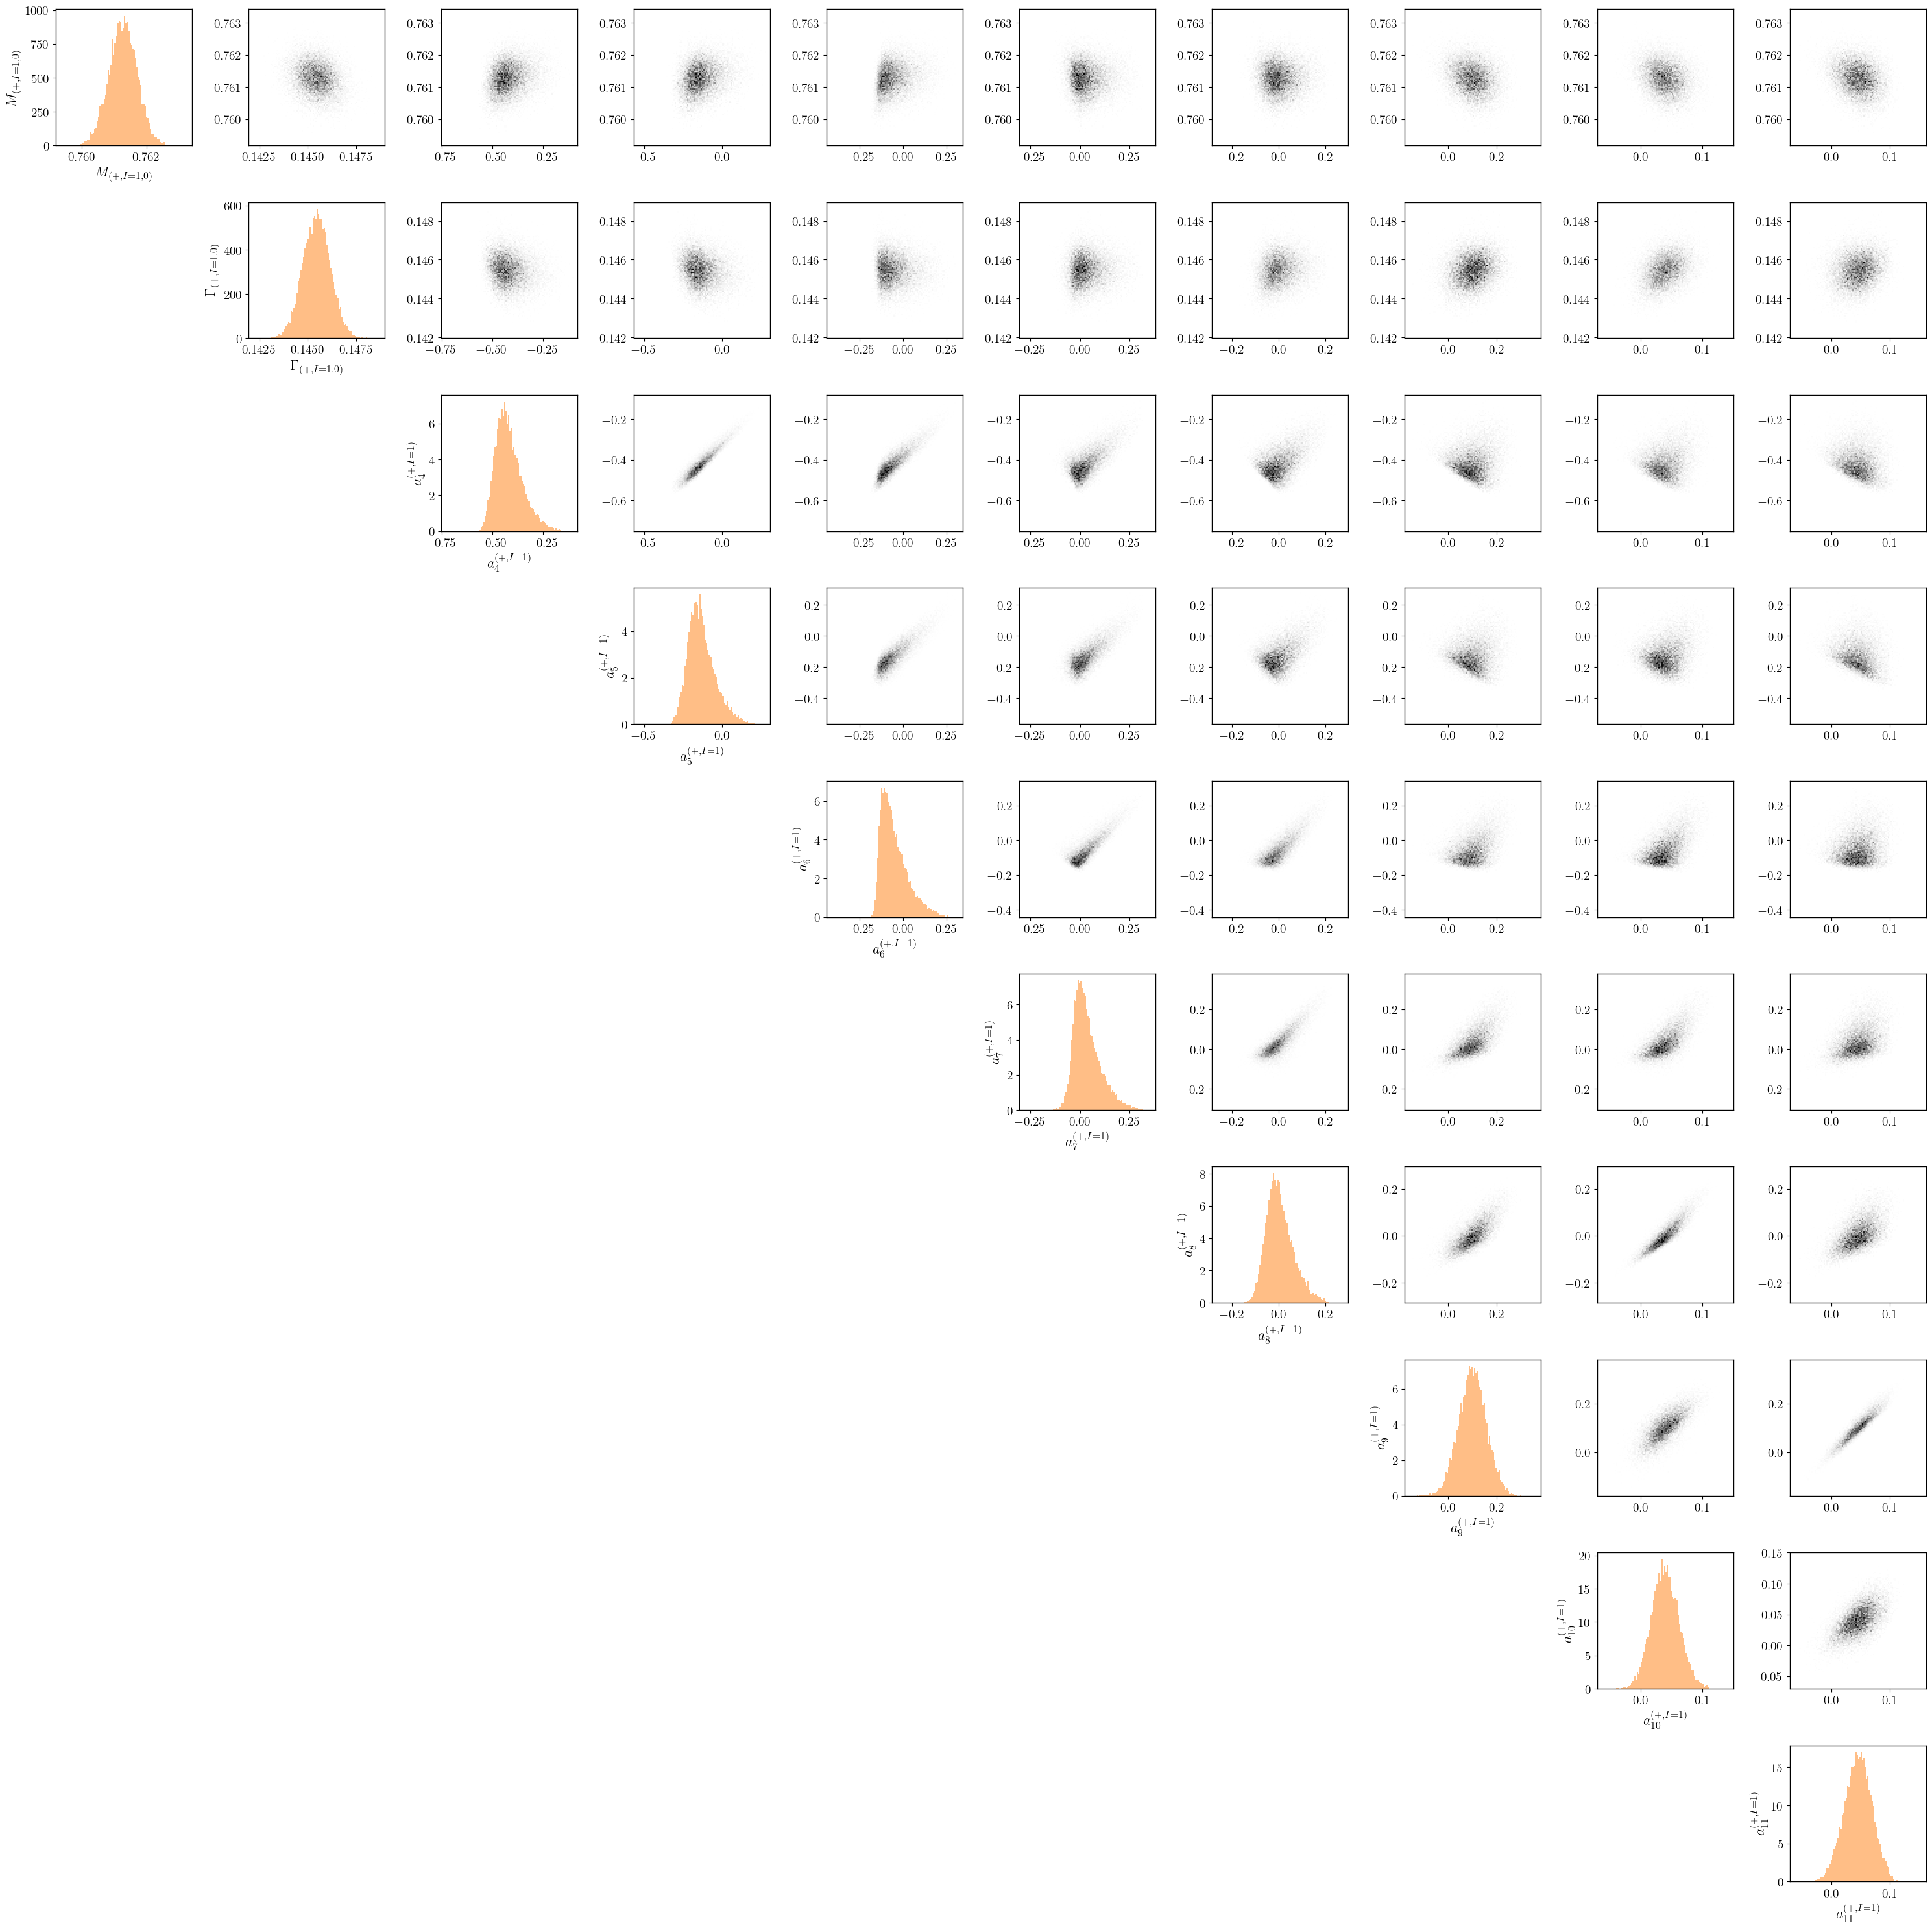

In [65]:
eos.tasks.corner_plot(af, posterior, base_directory=BASE_DIRECTORY)

In [68]:
print(f"rho mass  = {np.average(f.samples[:,0], weights=f.weights):.4f} ± {wstd(f.samples[:,0], weights=f.weights):.4f}")
print(f"rho width = {np.average(f.samples[:,1], weights=f.weights):.4f} ± {wstd(f.samples[:,1], weights=f.weights):.4f}")

rho mass  = 0.7613 ± 0.0004
rho width = 0.1455 ± 0.0007


In [69]:
# Dispersive bound computation
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-dispersive-bound", base_directory=BASE_DIRECTORY)
preds = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-dispersive-bound'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order11/p…

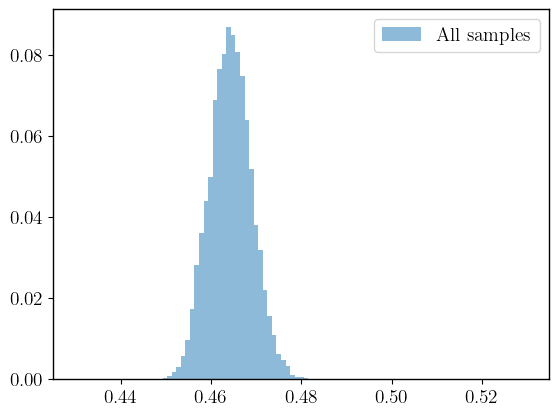

In [70]:
plt.hist(preds.samples, weights=preds.weights, bins=np.linspace(0.43,0.53,100), alpha=0.5, label='All samples')
plt.legend()
plt.show()

In [71]:
disp_values = np.array(preds.samples[:,0])
disp_mean   = np.average(disp_values, weights=preds.weights)
disp_std    = wstd(disp_values, weights=preds.weights)
print(f"Dispersive bound is {disp_mean:.4f} ± {disp_std:.4f}")

Dispersive bound is 0.4643 ± 0.0046


In [72]:
eos.tasks.predict_observables(af, posterior, "FF-fp2-I1-all", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order11/p…

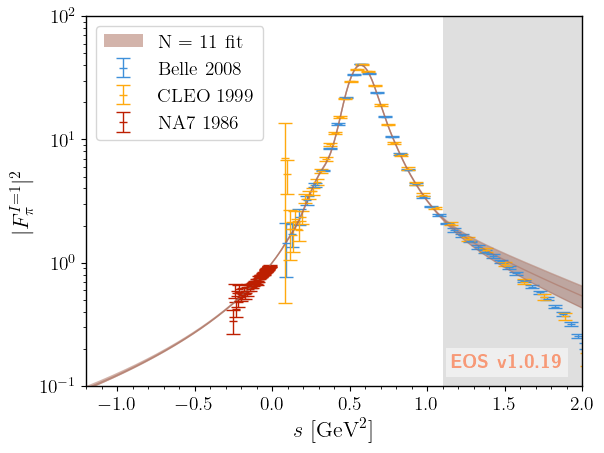

In [73]:
figure_args = {
'watermark': { 'position': 'lower right' },
'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [-1.2, 2.0] },
    'yaxis': { 'label': r'$|F^{I=1}_\pi|^2$', 'range': [ 0.1, 100.0], 'scale': 'log' },
    'legend': { 'position': 'upper left' },
    'items': [
    { 'type': 'constraint', 'label': 'Belle 2008', 'color': colors[0],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2)',
        'constraints': '0->pipi::Abs{f_+}^2@Belle:2008C',
    },
    { 'type': 'constraint', 'label': 'CLEO 1999', 'color': colors[1],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2)',
        'constraints': '0->pipi::Abs{f_+}^2@CLEO:2000B',
    },
    { 'type': 'constraint', 'label': 'NA7 1986', 'color': colors[2],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2)',
        'constraints': '0->pipi::Abs{f_+}^2@NA7:1986A',
    },
    { 'type': 'uncertainty', 'label': 'N = 11 fit', 'color': colors[5],
        'variable': 'q2', 'range': [-1.2, 2.0], 'interpolation': 'cubic',
        'datafile': 'data/'+posterior+'/pred-FF-fp2-I1-all', 'resolution': 300
    },
    { 'type': 'band', 'color': 'gray', 'alpha': 0.25, 'x': [1.1, 2.0], 'y': [0.0, 100]}
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [74]:
eos.tasks.predict_observables(af, posterior, "FF-arg-fp-I1-timelike", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order11/p…

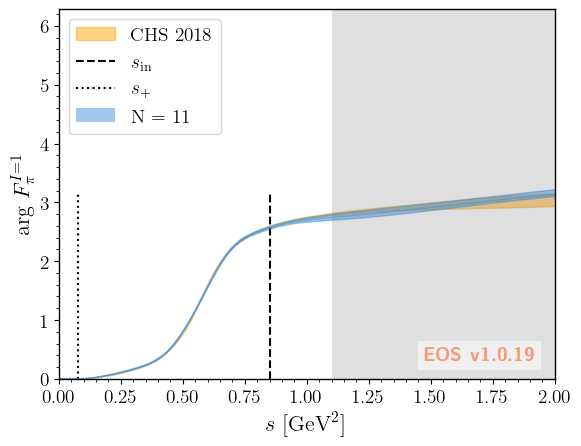

In [75]:
figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [0.0, 2.0] },
    'yaxis': { 'label': r'arg $F^{I=1}_\pi$', 'range': [0.0 , 2*np.pi] },
    'legend': { 'position': 'upper left' },
    'items': [
      { 'type': 'uncertainty', 'label': 'N = 11', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-FF-arg-fp-I1-timelike', 'color': colors[0]
      },
      { 'type': 'band', 'color': 'gray', 'alpha': 0.25, 'x': [1.1, 2.0], 'y': [0.0, 2*np.pi]}
    ]
  }
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)

q2_over_mpisquared, phase, err = np.loadtxt("scripts/d11-central.txt", skiprows=1, unpack=True)
mpi = eos.Parameters()["mass::pi^+"].evaluate()
q2  = q2_over_mpisquared * mpi**2

figure._ax.fill_between(q2, phase-err, phase+err, label="CHS 2018", alpha=0.5, color=colors[1])
figure._ax.plot([sIn, sIn], [0.0, np.pi], color='k', linestyle='--', label= r'$s_\mathrm{in}$')
figure._ax.plot([sPlus, sPlus], [0.0, np.pi], color='k', linestyle=':', label= r'$s_+$')
figure._ax.legend(loc="upper left")

figure.draw()

In [76]:
get_gof(analysis, start_point)
analysis.parameters.dump('data/'+posterior+'/mode-default/parameters.yaml')

Handling item to plot 0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026 in the complex plane
Overriding parameters from file
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,2)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(0,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(0,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,2)@KSvD2025' with central value '0'
[parameters.override] Overriding existing p

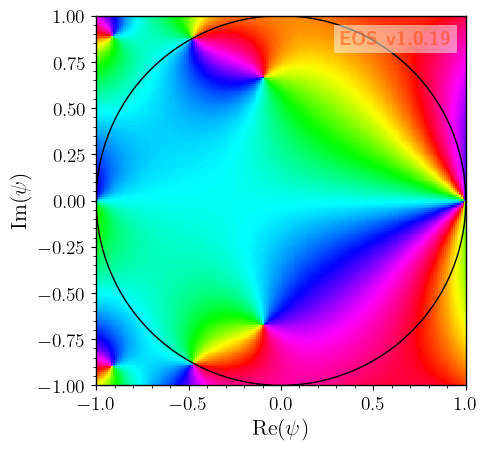

In [78]:
figure_args = {
'plot': {
    'xaxis': { 'label': r'$\mathrm{Re}(\psi)$', 'range': [-1.0, 1.0] },
    'yaxis': { 'label': r'$\mathrm{Im}(\psi)$', 'range': [-1.0, 1.0] },
    # 'legend': { 'position': 'upper left' },
    'items': [
    { 'type': 'complex-plane', 'label': 'N = 11 fit', 'colormap': 'hsv',
        'variables': ["Re{psi}", "Im{psi}"], 'observable': "0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026",
        'fixed_parameters_from_file': 'data/'+posterior+'/mode-default/parameters.yaml', 'resolution': 200
    }
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()
circle = plt.Circle((0, 0), 1.0, color='k', fill=False)
figure._ax.add_patch(circle)
figure._ax.set_aspect("equal", adjustable="box")

In [79]:
eos.tasks.predict_observables(af, posterior, "real-partial-wave-I1", base_directory=BASE_DIRECTORY)
eos.tasks.predict_observables(af, posterior, "imag-partial-wave-I1", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order11/p…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order11/p…

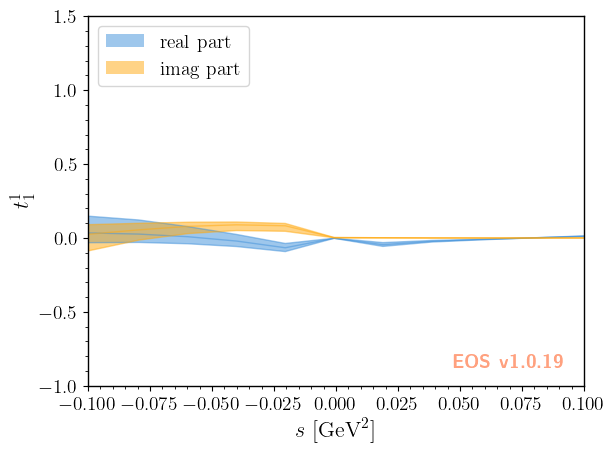

In [25]:
figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [-0.1, 0.1] },
    'yaxis': { 'label': '$t_1^1$',  'range': [-1.0, 1.5]},
    'legend': { 'position': 'upper left' },
    'items': [
      { 'type': 'uncertainty', 'label': 'real part', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-real-partial-wave-I1'
      },
      { 'type': 'uncertainty', 'label': 'imag part', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-imag-partial-wave-I1'
      },
    ]
  }
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [81]:
# Analytic value of a11
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-scattering-length-params", base_directory=BASE_DIRECTORY)
sl_params = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-scattering-length-params'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order11/p…

In [82]:
a11_values = np.array(list(map(a11_calculator, sl_params.samples)))* mpi**2
a11_mean   = np.average(a11_values, weights=sl_params.weights)
a11_std    = wstd(a11_values, weights=sl_params.weights)
print(f"a11 = {a11_mean:.4f} ± {a11_std:.4f}")

a11 = 0.0117 ± 0.0019


In [83]:
# Charge radius
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-pion-charge-radius-param", base_directory=BASE_DIRECTORY)
fprime_values = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-pion-charge-radius-param'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order11/p…

In [84]:
charge_radius_squared_values = np.array(list(map(charge_radius_squared_calculator, fprime_values.samples[:, 0])))
radius_mean = np.average(charge_radius_squared_values, weights=fprime_values.weights)
radius_std  = wstd(charge_radius_squared_values, weights=fprime_values.weights)
print(f"<r^2> = {radius_mean:.4f} ± {radius_std:.4f} fm^2")

<r^2> = 0.4231 ± 0.0039 fm^2


In [85]:
# Residue at the rho pole
eos.tasks.predict_observables(af, posterior, "re-rho-residue-psi", base_directory=BASE_DIRECTORY)
re_res_psi = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-re-rho-residue-psi'))
eos.tasks.predict_observables(af, posterior, "im-rho-residue-psi", base_directory=BASE_DIRECTORY)
im_res_psi = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-im-rho-residue-psi'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order11/p…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order11/p…

In [86]:
re_res = re_res_psi.samples[:,0]
im_res = im_res_psi.samples[:,0]
M      = f.samples[:,0]
Gamma  = f.samples[:,1]

print(len(re_res), len(im_res), len(M), len(Gamma)) # check that they have the same length

16511 16511 16511 16511


In [87]:
data = []

for r, i, m, g in zip(re_res, im_res, M, Gamma):
    data.append([r, i, m, g])

with open("residues_psi_order11.wl", "w") as file:
    lines = [f"{{{r}, {i}, {m}, {g}}}" for r, i, m, g in data]
    file.write("{\n" + ",\n".join(lines) + "\n}")

In [95]:
with open("residues_s_order11.wl") as file:
    text = file.read()

# Replace Mathematica braces with Python brackets
text = text.replace("{", "[").replace("}", "]")

data = ast.literal_eval(text)

FileNotFoundError: [Errno 2] No such file or directory: 'residues_s_order11.wl'

In [ ]:
res_s       = np.array([re + 1j * im for re, im in data])
res_s_mean  = np.average(res_s, weights=f.weights)
radius_std  = wstd(res_s, weights=f.weights)
print(f"residue at s_rho is ({np.real(res_s_mean):.4f} ± {np.real(radius_std):.4f}) + i * ({np.imag(res_s_mean):.4f} ± {np.imag(radius_std):.4f})")

residue at s_rho is (-0.6812 ± 0.0076) + i * (0.1773 ± 0.0181)


In [ ]:
# Computing g_{rho pi pi} and g_{rho gamma}
f_at_s_rho       = np.array([get_f_rho(s, analysis) for s in f.samples])
f_at_s_rho_value = f_at_s_rho[:,0] + 1j * f_at_s_rho[:,1]

In [ ]:
s_rho       = (M - 1j * Gamma / 2)**2
g_rho_gamma = np.sqrt(24j * np.pi * s_rho / f_at_s_rho_value / res_s / (np.sqrt(1 - sPlus / s_rho))**3)
g_rho_pi_pi = - res_s / s_rho * g_rho_gamma

In [ ]:
g_rho_gamma_mean = np.average(g_rho_gamma, weights=f.weights)
g_rho_gamma_std  = wstd(g_rho_gamma, weights=f.weights)
print(f"g_rho_gamma =  ({np.real(g_rho_gamma_mean):.4f} ± {np.real(g_rho_gamma_std):.4f}) + i * ({np.imag(g_rho_gamma_mean):.4f} ± {np.imag(g_rho_gamma_std):.4f})")

g_rho_pi_pi_mean = np.average(g_rho_pi_pi, weights=f.weights)
g_rho_pi_pi_std  = wstd(g_rho_pi_pi, weights=f.weights)
print(f"g_rho_pi_pi =  ({np.real(g_rho_pi_pi_mean):.4f} ± {np.real(g_rho_pi_pi_std):.4f}) + i * ({np.imag(g_rho_pi_pi_mean):.4f} ± {np.imag(g_rho_pi_pi_std):.4f})")

g_rho_gamma = 4.8573-0.5807j ± 0.0043+0.0032j
g_rho_pi_pi = 5.7400+0.0110j ± 0.0272+0.1512j


## 0 -> pi pi order 12

In [37]:
posterior = 'FF-fp-I1-order12'
analysis  = af.analysis(posterior)

Creating analysis with 11 priors, 3 EOS-wide constraints, 2 global options, 2 manually-entered constraints and 2 fixed parameters.
likelihood probably depends on 6 parameter(s) that do not appear in the prior; check prior?


In [38]:
start_point = [0.76092952,  0.14469899, -0.62802389, -0.28290906, -0.23151091,
        0.01629697,  0.02867426,  0.16840731,  0.15029998,  0.07712514,
        0.04589629]

In [39]:
get_gof(analysis, start_point)

In [40]:
#bfp, gof = eos.tasks.find_mode(af, posterior, start_point=start_point, base_directory=BASE_DIRECTORY, optimizations=100)
bfp, gof = eos.tasks.find_mode(af, posterior, importance_samples=True, base_directory=BASE_DIRECTORY, optimizations=100)
display(gof)
bfp.point

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order12/m…

array([ 0.76085988,  0.14455695, -0.67456986, -0.30870621, -0.25125305,
        0.0463504 ,  0.07312831,  0.21917789,  0.20765785,  0.09576268,
        0.06722566])

In [41]:
if resample:
    eos.tasks.sample_nested(af, posterior, base_directory=BASE_DIRECTORY, bound='multi', nlive=100)

f = eos.data.ImportanceSamples(os.path.join(BASE_DIRECTORY, 'data', posterior, 'samples'))
print(f"Collected {f.samples.shape[0]} samples")

Collected 19269 samples


In [42]:
for i, p in enumerate(analysis.varied_parameters):
    mean = np.average(f.samples[:,i], weights=f.weights)
    std = wstd(f.samples[:,i], weights=f.weights)
    print(f"      - {{ 'parameter': '{p.name()}', 'min':  {mean - 6*std:.5f}, 'max':  {mean + 6*std:.5f}, 'type': 'uniform'}}")

      - { 'parameter': '0->pipi::M_(+,1,0)@BHKMNR2026', 'min':  0.75862, 'max':  0.76383, 'type': 'uniform'}
      - { 'parameter': '0->pipi::Gamma_(+,1,0)@BHKMNR2026', 'min':  0.14049, 'max':  0.14940, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^4@BHKMNR2026', 'min':  -1.00202, 'max':  -0.11330, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^5@BHKMNR2026', 'min':  -0.76970, 'max':  0.27994, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^6@BHKMNR2026', 'min':  -0.57708, 'max':  0.30981, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^7@BHKMNR2026', 'min':  -0.29621, 'max':  0.38995, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^8@BHKMNR2026', 'min':  -0.19637, 'max':  0.37198, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^9@BHKMNR2026', 'min':  -0.08826, 'max':  0.46023, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^10@BHKMNR2026', 'min':  -0.08524, 'max':  0.43928, 'type': 'uniform'}
      

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order12/p…

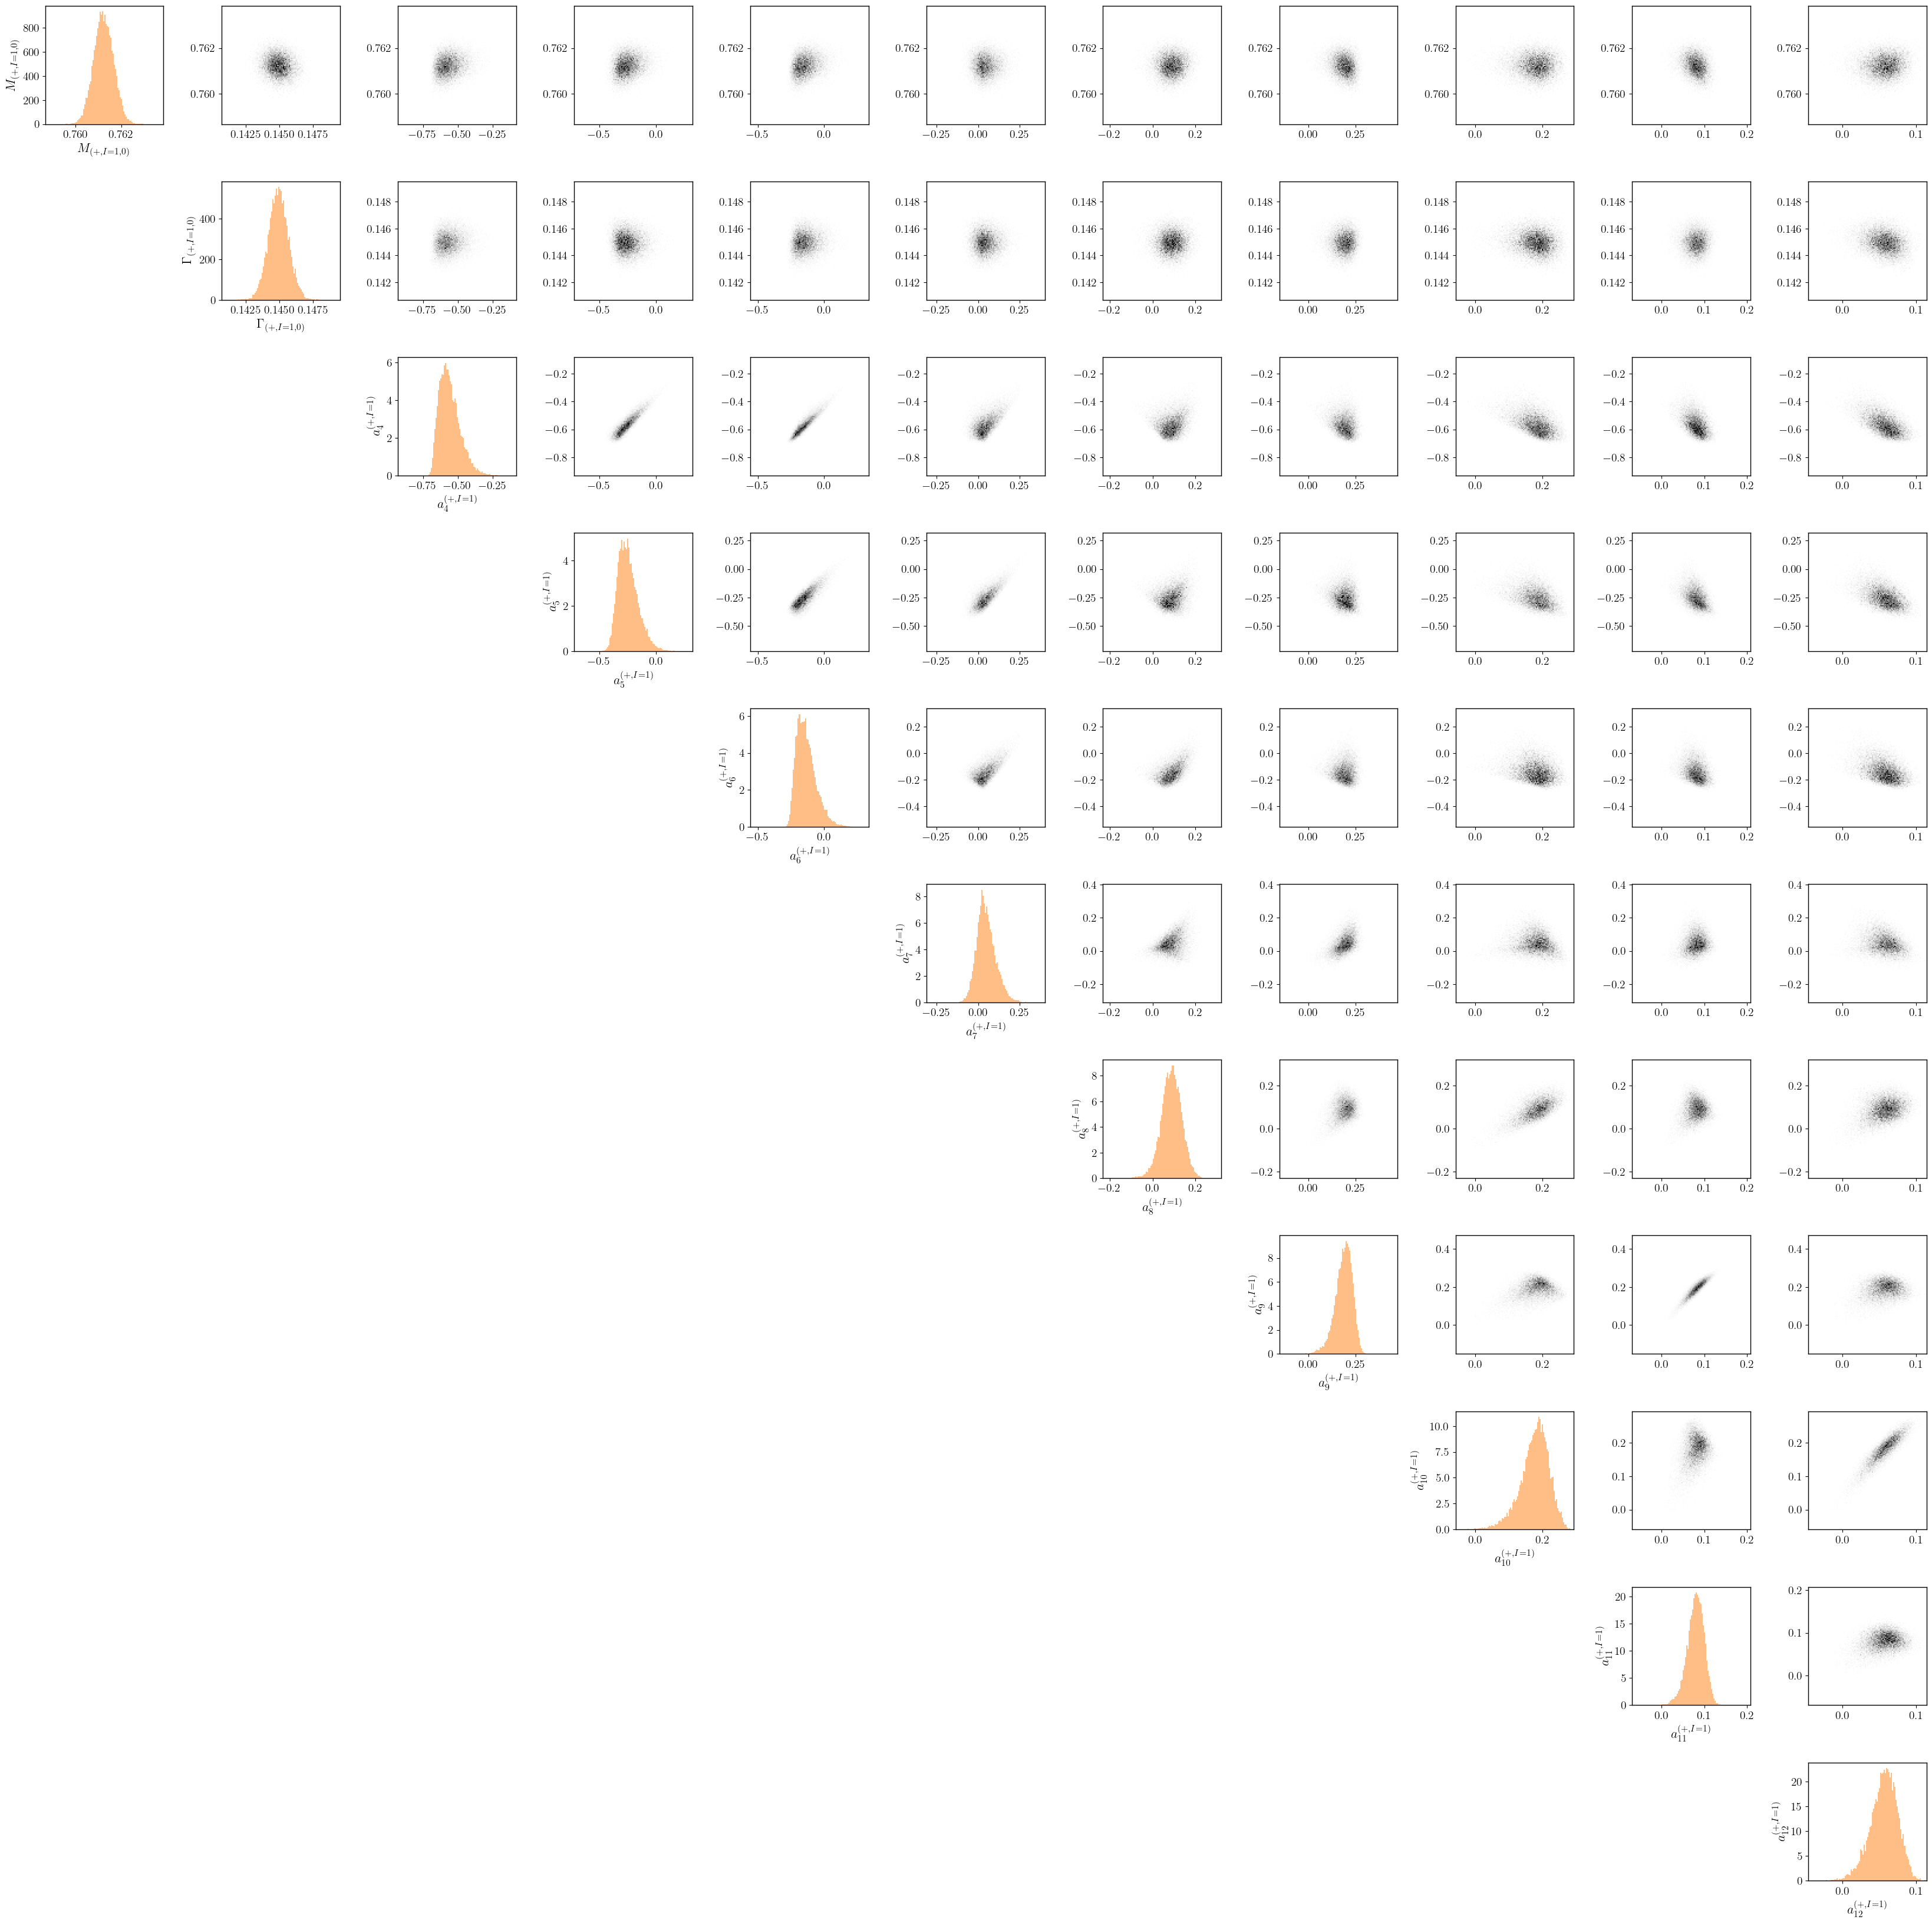

In [43]:
if not resample:
    eos.tasks.corner_plot(af, posterior, base_directory=BASE_DIRECTORY)

In [44]:
print(f"rho mass  = {np.average(f.samples[:,0], weights=f.weights):.4f} ± {wstd(f.samples[:,0], weights=f.weights):.4f}")
print(f"rho width = {np.average(f.samples[:,1], weights=f.weights):.4f} ± {wstd(f.samples[:,1], weights=f.weights):.4f}")

rho mass  = 0.7612 ± 0.0004
rho width = 0.1449 ± 0.0007


In [45]:
# Dispersive bound computation
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-dispersive-bound", base_directory=BASE_DIRECTORY)
preds = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-dispersive-bound'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order12/p…

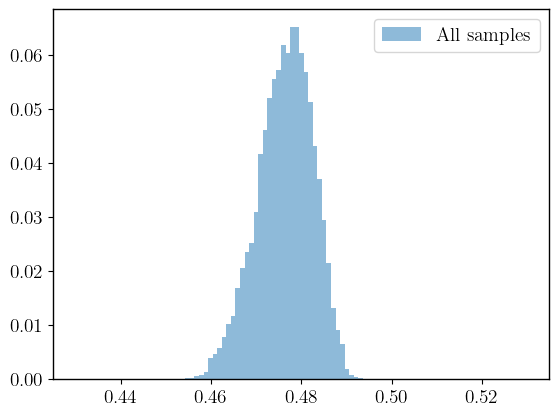

In [46]:
plt.hist(preds.samples, weights=preds.weights, bins=np.linspace(0.43,0.53,100), alpha=0.5, label='All samples')
plt.legend()
plt.show()

In [47]:
disp_values = np.array(preds.samples[:,0])
disp_mean   = np.average(disp_values, weights=preds.weights)
disp_std    = wstd(disp_values, weights=preds.weights)
print(f"Dispersive bound is {disp_mean:.4f} ± {disp_std:.4f}")

Dispersive bound is 0.4764 ± 0.0061


In [48]:
eos.tasks.predict_observables(af, posterior, "FF-fp2-I1-all", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order12/p…

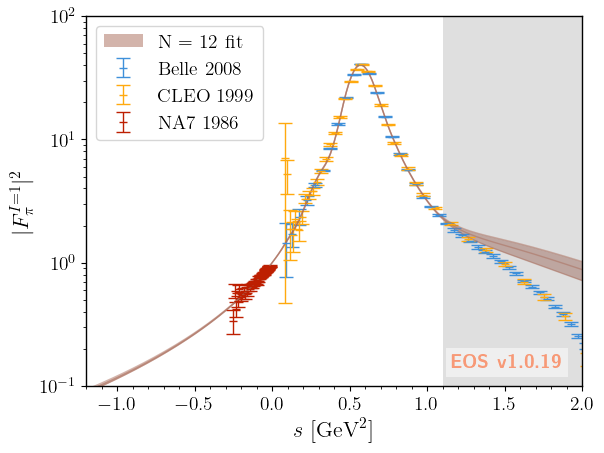

In [49]:
figure_args = {
'watermark': { 'position': 'lower right' },
'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [-1.2, 2.0] },
    'yaxis': { 'label': r'$|F^{I=1}_\pi|^2$', 'range': [ 0.1, 100.0], 'scale': 'log' },
    'legend': { 'position': 'upper left' },
    'items': [
    { 'type': 'constraint', 'label': 'Belle 2008', 'color': colors[0],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2)',
        'constraints': '0->pipi::Abs{f_+}^2@Belle:2008C',
    },
    { 'type': 'constraint', 'label': 'CLEO 1999', 'color': colors[1],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2)',
        'constraints': '0->pipi::Abs{f_+}^2@CLEO:2000B',
    },
    { 'type': 'constraint', 'label': 'NA7 1986', 'color': colors[2],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2)',
        'constraints': '0->pipi::Abs{f_+}^2@NA7:1986A',
    },
    { 'type': 'uncertainty', 'label': 'N = 12 fit', 'color': colors[5],
        'variable': 'q2', 'range': [-1.2, 2.0], 'interpolation': 'cubic',
        'datafile': 'data/'+posterior+'/pred-FF-fp2-I1-all', 'resolution': 300
    },
    { 'type': 'band', 'color': 'gray', 'alpha': 0.25, 'x': [1.1, 2.0], 'y': [0.0, 100]}
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [50]:
eos.tasks.predict_observables(af, posterior, "FF-arg-fp-I1-timelike", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order12/p…

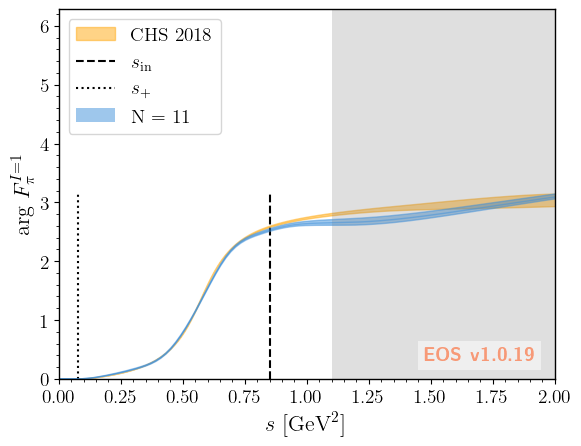

In [51]:
figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [0.0, 2.0] },
    'yaxis': { 'label': r'arg $F^{I=1}_\pi$', 'range': [0.0 , 2*np.pi] },
    'legend': { 'position': 'upper left' },
    'items': [
      { 'type': 'uncertainty', 'label': 'N = 11', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-FF-arg-fp-I1-timelike', 'color': colors[0]
      },
      { 'type': 'band', 'color': 'gray', 'alpha': 0.25, 'x': [1.1, 2.0], 'y': [0.0, 2*np.pi]}
    ]
  }
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)

q2_over_mpisquared, phase, err = np.loadtxt("scripts/d11-central.txt", skiprows=1, unpack=True)
mpi = eos.Parameters()["mass::pi^+"].evaluate()
q2  = q2_over_mpisquared * mpi**2

figure._ax.fill_between(q2, phase-err, phase+err, label="CHS 2018", alpha=0.5, color=colors[1])
figure._ax.plot([sIn, sIn], [0.0, np.pi], color='k', linestyle='--', label= r'$s_\mathrm{in}$')
figure._ax.plot([sPlus, sPlus], [0.0, np.pi], color='k', linestyle=':', label= r'$s_+$')
figure._ax.legend(loc="upper left")

figure.draw()

In [52]:
get_gof(analysis, start_point)
analysis.parameters.dump('data/'+posterior+'/mode-default/parameters.yaml')

Handling item to plot 0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026 in the complex plane
Overriding parameters from file
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,2)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(0,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(0,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,2)@KSvD2025' with central value '0'
[parameters.override] Overriding existing p

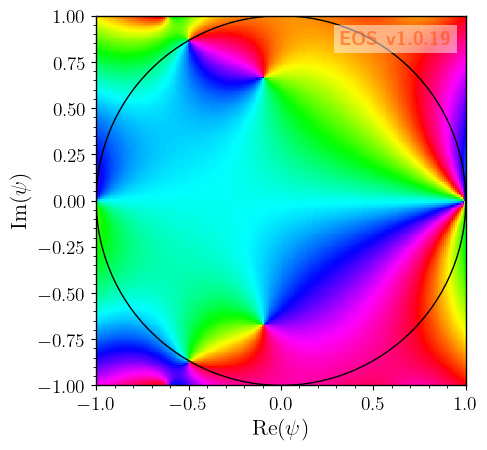

In [55]:
figure_args = {
'plot': {
    'xaxis': { 'label': r'$\mathrm{Re}(\psi)$', 'range': [-1.0, 1.0] },
    'yaxis': { 'label': r'$\mathrm{Im}(\psi)$', 'range': [-1.0, 1.0] },
    # 'legend': { 'position': 'upper left' },
    'items': [
    { 'type': 'complex-plane', 'label': 'N = 11 fit', 'colormap': 'hsv',
        'variables': ["Re{psi}", "Im{psi}"], 'observable': "0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026",
        'fixed_parameters_from_file': 'data/'+posterior+'/mode-default/parameters.yaml', 'resolution': 200
    }
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()
circle = plt.Circle((0, 0), 1.0, color='k', fill=False)
figure._ax.add_patch(circle)
figure._ax.set_aspect("equal", adjustable="box")

In [56]:
eos.tasks.predict_observables(af, posterior, "real-partial-wave-I1", base_directory=BASE_DIRECTORY)
eos.tasks.predict_observables(af, posterior, "imag-partial-wave-I1", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order12/p…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order12/p…

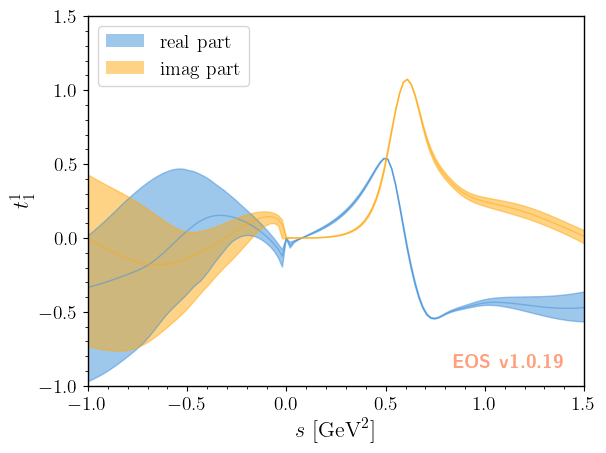

In [57]:
figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [-1.0, 1.5] },
    'yaxis': { 'label': '$t_1^1$',  'range': [-1.0, 1.5]},
    'legend': { 'position': 'upper left' },
    'items': [
      { 'type': 'uncertainty', 'label': 'real part', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-real-partial-wave-I1'
      },
      { 'type': 'uncertainty', 'label': 'imag part', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-imag-partial-wave-I1'
      },
    ]
  }
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [58]:
# Analytic value of a11
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-scattering-length-params", base_directory=BASE_DIRECTORY)
sl_params = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-scattering-length-params'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order12/p…

In [59]:
a11_values = np.array(list(map(a11_calculator, sl_params.samples)))* mpi**2
a11_mean   = np.average(a11_values, weights=sl_params.weights)
a11_std    = wstd(a11_values, weights=sl_params.weights)
print(f"a11 = {a11_mean:.4f} ± {a11_std:.4f}")

a11 = 0.0127 ± 0.0021


In [60]:
# Charge radius
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-pion-charge-radius-param", base_directory=BASE_DIRECTORY)
fprime_values = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-pion-charge-radius-param'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order12/p…

In [61]:
charge_radius_squared_values = np.array(list(map(charge_radius_squared_calculator, fprime_values.samples[:, 0])))
radius_mean = np.average(charge_radius_squared_values, weights=fprime_values.weights)
radius_std  = wstd(charge_radius_squared_values, weights=fprime_values.weights)
print(f"<r^2> = {radius_mean:.4f} ± {radius_std:.4f} fm^2")

<r^2> = 0.4270 ± 0.0043 fm^2


In [62]:
# Residue at the rho pole
eos.tasks.predict_observables(af, posterior, "re-rho-residue-psi", base_directory=BASE_DIRECTORY)
re_res_psi = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-re-rho-residue-psi'))
eos.tasks.predict_observables(af, posterior, "im-rho-residue-psi", base_directory=BASE_DIRECTORY)
im_res_psi = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-im-rho-residue-psi'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order12/p…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order12/p…

In [63]:
re_res = re_res_psi.samples[:,0]
im_res = im_res_psi.samples[:,0]
M      = f.samples[:,0]
Gamma  = f.samples[:,1]

print(len(re_res), len(im_res), len(M), len(Gamma)) # check that they have the same length

19269 19269 19269 19269


In [64]:
data = []

for r, i, m, g in zip(re_res, im_res, M, Gamma):
    data.append([r, i, m, g])

with open("residues_psi_order12.wl", "w") as file:
    lines = [f"{{{r}, {i}, {m}, {g}}}" for r, i, m, g in data]
    file.write("{\n" + ",\n".join(lines) + "\n}")

In [ ]:
with open("residues_s_order12.wl") as file:
    text = file.read()

# Replace Mathematica braces with Python brackets
text = text.replace("{", "[").replace("}", "]")

data = ast.literal_eval(text)

FileNotFoundError: [Errno 2] No such file or directory: 'residues_s_order11.wl'

In [ ]:
res_s       = np.array([re + 1j * im for re, im in data])
res_s_mean  = np.average(res_s, weights=f.weights)
radius_std  = wstd(res_s, weights=f.weights)
print(f"residue at s_rho is ({np.real(res_s_mean):.4f} ± {np.real(radius_std):.4f}) + i * ({np.imag(res_s_mean):.4f} ± {np.imag(radius_std):.4f})")

residue at s_rho is (-0.6812 ± 0.0076) + i * (0.1773 ± 0.0181)


In [ ]:
# Computing g_{rho pi pi} and g_{rho gamma}
f_at_s_rho       = np.array([get_f_rho(s, analysis) for s in f.samples])
f_at_s_rho_value = f_at_s_rho[:,0] + 1j * f_at_s_rho[:,1]

In [ ]:
s_rho       = (M - 1j * Gamma / 2)**2
g_rho_gamma = np.sqrt(24j * np.pi * s_rho / f_at_s_rho_value / res_s / (np.sqrt(1 - sPlus / s_rho))**3)
g_rho_pi_pi = - res_s / s_rho * g_rho_gamma

In [ ]:
g_rho_gamma_mean = np.average(g_rho_gamma, weights=f.weights)
g_rho_gamma_std  = wstd(g_rho_gamma, weights=f.weights)
print(f"g_rho_gamma =  ({np.real(g_rho_gamma_mean):.4f} ± {np.real(g_rho_gamma_std):.4f}) + i * ({np.imag(g_rho_gamma_mean):.4f} ± {np.imag(g_rho_gamma_std):.4f})")

g_rho_pi_pi_mean = np.average(g_rho_pi_pi, weights=f.weights)
g_rho_pi_pi_std  = wstd(g_rho_pi_pi, weights=f.weights)
print(f"g_rho_pi_pi =  ({np.real(g_rho_pi_pi_mean):.4f} ± {np.real(g_rho_pi_pi_std):.4f}) + i * ({np.imag(g_rho_pi_pi_mean):.4f} ± {np.imag(g_rho_pi_pi_std):.4f})")

g_rho_gamma = 4.8573-0.5807j ± 0.0043+0.0032j
g_rho_pi_pi = 5.7400+0.0110j ± 0.0272+0.1512j
